# 다이캐스팅 불량 예측 프로젝트 (VSCode)
## Die-Casting Quality Prediction Pipeline (Production-Grade)

> **목표**: 공정(Process) + 센서(Sensor) 데이터를 활용하여 이진 분류 (양품 / 불량) 모델을 구축하고,  
> 불량 발생의 주요 원인 변수를 분석하여 공정 최적화 인사이트를 도출한다.

---

**파이프라인 구성**

| 단계 | 내용 |
|------|------|
| 0 | 패키지 설치 (pip) & 한글 폰트 자동 설정 |
| 1 | 라이브러리 & 데이터 로드 |
| 2 | 데이터 기본 파악 |
| 3 | EDA (탐색적 데이터 분석) |
| ↳ 3-1 | 타겟 변수 생성 & 불량률 파악 |
| ↳ 3-2 | 불량 유형별 발생 빈도 |
| ↳ 3-3 | **불량 유형별 공정변수 분포 비교** |
| ↳ 3-4 | 공정 변수 분포 (양품 vs 불량 비교) |
| ↳ 3-5 | 상관 행렬 & 다중공선성 확인 |
| ↳ 3-6 | 이상치 탐색 (IQR) |
| ↳ 3-7 | 통계 검정: Welch's t-test |
| ↳ 3-8 | **ANOVA 분석** |
| 4 | 데이터 전처리 |
| ↳ 4-1 | 피처 & 타겟 정의 + 분산=0 컬럼 제거 |
| ↳ 4-2 | **VIF 다중공선성 분석** |
| ↳ 4-3 | 결측치 처리 (중앙값 대체) |
| ↳ 4-4 | 이상치 클리핑 (IQR factor=3.0) |
| ↳ 4-5 | 학습 / 테스트 분할 (stratify, 8:2) |
| 5 | 머신러닝 모델 학습 & 평가 |
| ↳ 5-1 | **베이스라인 모델 비교 (RF / LightGBM / XGBoost)** |
| ↳ 5-2 | Binary 최종 모델 (Leak-free CV · Calibration · 비용 기반 Threshold) |
| ↳ 5-3 | Top 3 불량 유형 다중분류 (4-class, SMOTE) |
| ↳ 5-4 | Binary 모델 성능 시각화 |
| 6 | 중요 변수 분석 (Permutation + XGBoost gain) |
| 7 | SHAP 해석 (전역 / 국소) |
| ↳ 7-1 | 공정 최적화 리포트 자동 생성 (Markdown) |


**(무엇/왜/어떻게)**

- **무엇**: 필요 패키지 pip 설치 & 크로스플랫폼 한글 폰트 자동 설정
- **왜**: VSCode/로컬 Jupyter 환경에서는 Colab과 달리 패키지를 직접 설치해야 하고, 한글 폰트도 OS에 맞게 자동 선택해야 함.
- **어떻게**: pip install로 xgboost/imbalanced-learn/shap 설치 후, 설치된 폰트 목록을 검색해 OS별 최적 한글 폰트를 자동 선택.
- **VSCode 한글 폰트**: NanumGothic을 사용하려면 [나눔글꼴 다운로드](https://hangeul.naver.com/font) 후 시스템에 설치하거나, `set_korean_font(nanum_path='경로/NanumGothic.ttf')` 처럼 경로를 직접 지정해야 함.


In [1]:
# ── [환경 설정] 패키지 설치 & 크로스플랫폼 한글 폰트 설정 ────────────────────
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('xgboost', 'lightgbm', 'imbalanced-learn', 'shap', 'statsmodels', 'opencv-python')

# ── 크로스플랫폼 한글 폰트 자동 설정 ────────────────────────────────────────
import os, platform
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def set_korean_font(nanum_path=None):
    """NanumGothic 우선, 없으면 OS 기본 한글 폰트로 fallback."""
    available = {f.name for f in fm.fontManager.ttflist}
    if 'NanumGothic' in available:
        plt.rcParams['font.family'] = 'NanumGothic'
    elif nanum_path and os.path.exists(nanum_path):
        fm.fontManager.addfont(nanum_path)
        plt.rcParams['font.family'] = fm.FontProperties(fname=nanum_path).get_name()
    else:
        sysname = platform.system()
        if sysname == 'Windows':
            for cand in ['Malgun Gothic', 'NanumGothic']:
                if cand in available:
                    plt.rcParams['font.family'] = cand
                    break
        elif sysname == 'Darwin':
            for cand in ['AppleGothic', 'NanumGothic', 'Apple SD Gothic Neo']:
                if cand in available:
                    plt.rcParams['font.family'] = cand
                    break
        else:
            for cand in ['NanumGothic', 'NanumBarunGothic', 'Noto Sans CJK KR', 'DejaVu Sans']:
                if cand in available:
                    plt.rcParams['font.family'] = cand
                    break
    plt.rcParams['axes.unicode_minus'] = False
    print(f"한글 폰트 설정 완료: {plt.rcParams['font.family']}")

set_korean_font()
plt.rcParams['figure.figsize'] = (10, 5)
print('환경 설정 완료')


한글 폰트 설정 완료: ['Malgun Gothic']
환경 설정 완료


## 1️. 라이브러리 & 데이터 로드

**(무엇/왜/어떻게)**

- **무엇**: 분석에 필요한 기본 라이브러리 불러오기
- **왜**: 데이터 처리(NumPy/Pandas), 시각화(Matplotlib/Seaborn), 경고 관리 등을 위해.
- **어떻게**: 필요한 패키지를 import 하고, 표시 옵션/시각화 기본값을 설정.


In [2]:
# ── 기본 라이브러리 ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── 시각화 설정 ──────────────────────────────────────────────
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#4C72B0', '#DD8452']

set_korean_font()

# ── 사이킷런 & 모델 라이브러리 ───────────────────────────────
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing     import StandardScaler
from sklearn.ensemble          import RandomForestClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.metrics           import (classification_report, confusion_matrix,
                                        roc_auc_score, average_precision_score,
                                        precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.inspection        import permutation_importance
from sklearn.impute            import SimpleImputer

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline         import Pipeline as ImbPipeline
from imblearn.over_sampling    import SMOTE

print('라이브러리 로드 완료')


한글 폰트 설정 완료: ['Malgun Gothic']
라이브러리 로드 완료


**(무엇/왜/어떻게)**

- **무엇**: CSV 데이터 로드 및 헤더(컬럼명) 자동 복구
- **왜**: 원본 파일이 2줄 헤더/중복 헤더 형태라 그대로 읽으면 `Process.1` 같은 깨진 컬럼명이 생길 수 있음.
- **어떻게**: 2줄 헤더로 먼저 읽어 결합하고, 실패 시 다른 방식으로 재시도해 컬럼명을 정리함.


In [3]:
# ── 데이터 로드 (헤더 자동 복구) ─────────────────────────────────────────────
DATA_PATH = 'DieCasting_Quality_Raw_Data.csv'   # 같은 폴더에 위치

import pandas as pd
import numpy as np
import re

# 1) (권장) 2줄 헤더(Process/Defects)를 MultiIndex로 읽기
try:
    df_raw = pd.read_csv(DATA_PATH, header=[0, 1])
    # 각 헤더 파트의 공백을 먼저 정리한 뒤 join
    new_cols = []
    for a, b in df_raw.columns:
        a = str(a).strip()
        b = str(b).strip()
        b = re.sub(r'\s+', '_', b)   # 중간 공백 -> _
        new_cols.append(f"{a}_{b}".strip("_"))
    df_raw.columns = new_cols
except Exception:
    # 2) (fallback) 헤더가 2행이 아닐 경우(파일이 편집된 경우) 대비
    df_raw = pd.read_csv(DATA_PATH, header=1)
    df_raw.columns = [c.strip().replace(" ", "_") for c in df_raw.columns]

# 컬럼명 후처리(연속 언더스코어 제거)
df_raw.columns = [re.sub(r'_+', '_', c).strip('_') for c in df_raw.columns]

display(df_raw.head())
print("Rows:", len(df_raw), "| Cols:", df_raw.shape[1])

,Process_id,Process_Product_Type,Process_Shot,Process_Velocity_1,Process_Velocity_2,Process_Velocity_3,Process_High_Velocity,Process_Cylinder_Pressure,Process_Rapid_Rise_Time,Process_Biscuit_Thickness,Process_Clamping_Force,Process_Cycle_Time,Process_Pressure_Rise_Time,Process_Casting_Pressure,Process_Spray_Time,Process_Spray_1_Time,Process_Spray_2_Time,Sensor_Melting_Furnace_Temp,Sensor_Air_Pressure,Sensor_Air_Pressure_Min,Sensor_Air_Pressure_Max,Sensor_Coolant_Temp,Sensor_Coolant_Temp_Min,Sensor_Coolant_Temp_Max,Sensor_Coolant_Pressure,Sensor_Factory_Temp,Sensor_Factory_Temp_Min,Sensor_Factory_Temp_Max,Sensor_Factory_Humidity,Sensor_Factory_Humidity_Min,Sensor_Factory_Humidity_Max,Defects_Short_Shot_1,Defects_Bubble_1,Defects_Exfoliation_1,Defects_Blow_Hole_1,Defects_Stain_1,Defects_Dent_1,Defects_Deformation_1,Defects_Contamination_1,Defects_Impurity_1,Defects_Crack_1,Defects_Scratch_1,Defects_Buring_Mark_1,Defects_Inclusions_1,Defects_Short_Shot_2,Defects_Bubble_2,Defects_Exfoliation_2,Defects_Blow_Hole_2,Defects_Stain_2,Defects_Dent_2,Defects_Deformation_2,Defects_Contamination_2,Defects_Impurity_2,Defects_Crack_2,Defects_Scratch_2,Defects_Buring_Mark_2,Defects_Inclusions_2
0,1,1,1,0.1440,0.1700,0.1880,2.1340,214,0.0080,10,258,20.7000,0.0440,1037,7.8000,0.7000,0.8000,695.0000,6.3000,3,9,26.0000,10,50,2.7100,32.9000,18.0000,22.0000,58.4000,18.0000,22.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1002,1,2,0.1440,0.1700,0.1820,2.1240,217,0.0080,11,257,20.7000,0.0440,1052,7.8000,0.7000,0.8000,696.4000,6.3000,3,9,26.1000,10,50,2.6900,32.9000,18.0000,22.0000,58.2000,18.0000,22.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2003,1,3,0.1440,0.1700,0.1820,2.1160,214,0.0080,11,257,20.8000,0.0410,1037,7.8000,0.7000,0.8000,696.4000,6.3000,3,9,26.1000,10,50,2.6900,32.9000,18.0000,22.0000,58.2000,18.0000,22.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3004,1,4,0.1440,0.1700,0.1820,2.1370,217,0.0080,11,257,20.7000,0.0430,1051,7.8000,0.7000,0.8000,696.4000,6.3000,3,9,26.1000,10,50,2.6900,32.9000,18.0000,22.0000,58.2000,18.0000,22.0000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4005,1,5,0.1440,0.1720,0.1760,2.1110,217,0.0080,12,257,20.7000,0.0420,1052,7.8000,0.7000,0.8000,697.9000,6.4000,3,9,26.1000,10,50,2.6900,32.9000,18.0000,22.0000,57.8000,18.0000,22.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Rows: 7535 | Cols: 57


## 2️. 데이터 기본 파악

**(무엇/왜/어떻게)**

- **무엇**: Process/Sensor/Defect 컬럼을 자동으로 분류
- **왜**: 이후 EDA·모델링에서 어떤 컬럼을 입력 피처로 쓸지 일관되게 관리하기 위해서.
- **어떻게**: 컬럼 접두어(`Process_`, `Sensor_`)와 불량 라벨 패턴을 이용해 리스트를 만듦.


In [4]:
# ── 컬럼 분류 ────────────────────────────────────────────────
process_cols = [c for c in df_raw.columns if c.startswith('Process_') and c not in ['Process_id', 'Process_Product_Type', 'Process_Shot']]
sensor_cols  = [c for c in df_raw.columns if c.startswith('Sensor_')]
defect_cols_1 = [c for c in df_raw.columns if c.startswith('Defects_') and c.endswith('_1')]
defect_cols_2 = [c for c in df_raw.columns if c.startswith('Defects_') and c.endswith('_2')]

print('▶ 공정(Process) 변수:', len(process_cols), process_cols)
print()
print('▶ 센서(Sensor)  변수:', len(sensor_cols),  sensor_cols)
print()
print('▶ 불량(Defects) 변수(Cavity1):', len(defect_cols_1), defect_cols_1)
print()
print('▶ 불량(Defects) 변수(Cavity2):', len(defect_cols_2), defect_cols_2)


▶ 공정(Process) 변수: 14 ['Process_Velocity_1', 'Process_Velocity_2', 'Process_Velocity_3', 'Process_High_Velocity', 'Process_Cylinder_Pressure', 'Process_Rapid_Rise_Time', 'Process_Biscuit_Thickness', 'Process_Clamping_Force', 'Process_Cycle_Time', 'Process_Pressure_Rise_Time', 'Process_Casting_Pressure', 'Process_Spray_Time', 'Process_Spray_1_Time', 'Process_Spray_2_Time']

▶ 센서(Sensor)  변수: 14 ['Sensor_Melting_Furnace_Temp', 'Sensor_Air_Pressure', 'Sensor_Air_Pressure_Min', 'Sensor_Air_Pressure_Max', 'Sensor_Coolant_Temp', 'Sensor_Coolant_Temp_Min', 'Sensor_Coolant_Temp_Max', 'Sensor_Coolant_Pressure', 'Sensor_Factory_Temp', 'Sensor_Factory_Temp_Min', 'Sensor_Factory_Temp_Max', 'Sensor_Factory_Humidity', 'Sensor_Factory_Humidity_Min', 'Sensor_Factory_Humidity_Max']

▶ 불량(Defects) 변수(Cavity1): 13 ['Defects_Short_Shot_1', 'Defects_Bubble_1', 'Defects_Exfoliation_1', 'Defects_Blow_Hole_1', 'Defects_Stain_1', 'Defects_Dent_1', 'Defects_Deformation_1', 'Defects_Contamination_1', 'Defects_Imp

**(무엇/왜/어떻게)**

- **무엇**: 결측치(빈 값) 규모 확인
- **왜**: 결측치가 많으면 모델이 왜곡되거나 오류가 날 수 있어, 먼저 현황을 파악해야 함.
- **어떻게**: 컬럼별 결측치 개수 합계와 결측치가 존재하는 컬럼만 출력.


In [5]:
# ── 결측치 확인 ─────────────────────────────────────────────
missing = df_raw.isnull().sum()
print('결측치 합계:', missing.sum())
print(missing[missing > 0])


결측치 합계: 540
Sensor_Factory_Temp            90
Sensor_Factory_Temp_Min        90
Sensor_Factory_Temp_Max        90
Sensor_Factory_Humidity        90
Sensor_Factory_Humidity_Min    90
Sensor_Factory_Humidity_Max    90
dtype: int64


**(무엇/왜/어떻게)**

- **무엇**: 공정(Process) + 센서(Sensor) 변수의 기초 통계량 확인
- **왜**: 각 변수의 분포 범위, 평균, 표준편차를 파악해 이상치나 스케일 차이를 미리 파악하기 위해서.
- **어떻게**: `describe().T`로 변수별 통계량을 전치(transpose) 형태로 출력.


In [6]:
# ── 기초 통계 ─────────────────────────────────────────────
df_raw[process_cols + sensor_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Process_Velocity_1,7535.0000,0.1480,0.0070,0.1340,0.1420,0.1440,0.1560,0.1800
Process_Velocity_2,7535.0000,0.1690,0.0050,0.1580,0.1660,0.1680,0.1700,0.2120
Process_Velocity_3,7535.0000,0.1910,0.0120,0.1720,0.1810,0.1880,0.2020,0.2340
Process_High_Velocity,7535.0000,2.3190,0.2220,0.0000,2.1340,2.1610,2.5230,2.7440
Process_Cylinder_Pressure,7535.0000,239.6560,23.3050,107.0000,217.0000,239.0000,265.0000,266.0000
Process_Rapid_Rise_Time,7535.0000,0.0100,0.0020,0.0000,0.0080,0.0090,0.0120,0.0210
Process_Biscuit_Thickness,7535.0000,14.3100,3.2860,0.0000,11.0000,13.0000,17.0000,24.0000
Process_Clamping_Force,7535.0000,306.4330,57.2750,238.0000,255.0000,258.0000,372.0000,388.0000
Process_Cycle_Time,7535.0000,27.7360,8.7160,20.2000,20.9000,22.6000,35.9000,218.6000
Process_Pressure_Rise_Time,7535.0000,0.0390,0.0040,0.0000,0.0360,0.0410,0.0430,0.0460


## 3️. EDA (탐색적 데이터 분석)
### 3-1. 타겟 변수 생성 & 불량률 파악


**(무엇/왜/어떻게)**

- **무엇**: 이진 타겟(defect_any) 생성: 양품(0) vs 불량(1)
- **왜**: 실무에서 1차 목표는 ‘불량 여부 조기 경보’인 경우가 많고, 데이터 불균형에도 비교적 강함.
- **어떻게**: 불량 관련 컬럼(여러 유형)을 합산해 1개라도 있으면 1, 없으면 0으로 변환.


전체 Shot   : 7,535
불량 Shot   : 1,689  (22.4%)
양품 Shot   : 5,846 (77.6%)


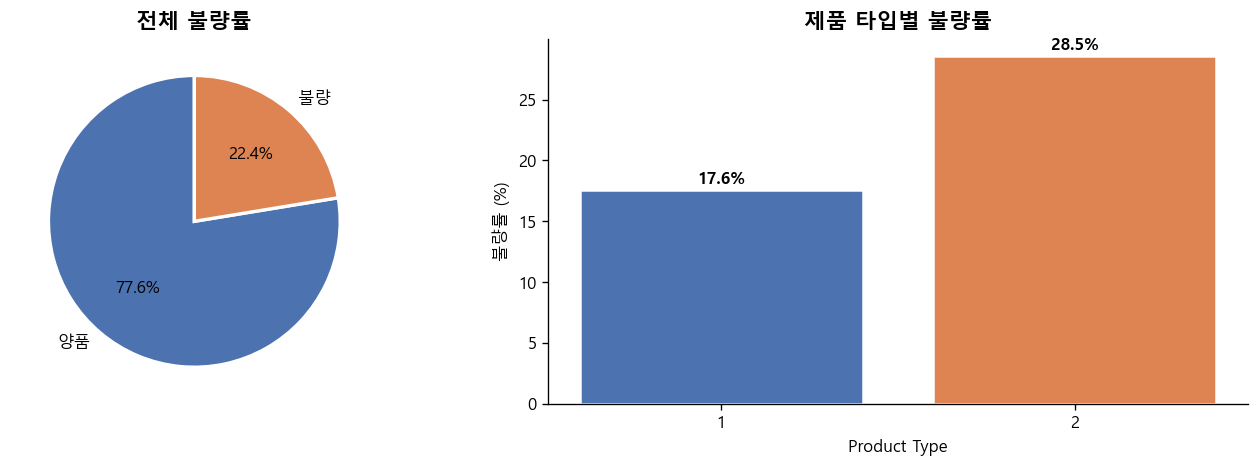

In [7]:
# ── 이진 타겟: 양품(0) / 불량(1) ────────────────────────────
df = df_raw.copy()
df['defect_any'] = ((df[defect_cols_1 + defect_cols_2].sum(axis=1)) > 0).astype(int)

total   = len(df)
n_bad   = df['defect_any'].sum()
n_good  = total - n_bad

print(f'전체 Shot   : {total:,}')
print(f'불량 Shot   : {n_bad:,}  ({n_bad/total*100:.1f}%)')
print(f'양품 Shot   : {n_good:,} ({n_good/total*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 파이 차트
axes[0].pie([n_good, n_bad], labels=['양품', '불량'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('전체 불량률', fontsize=13, fontweight='bold')

# 제품 타입별 불량률
type_defect = df.groupby('Process_Product_Type')['defect_any'].mean().reset_index()
type_defect.columns = ['Product_Type', 'Defect_Rate']
axes[1].bar(type_defect['Product_Type'].astype(str), type_defect['Defect_Rate']*100,
            color=PALETTE, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Product Type')
axes[1].set_ylabel('불량률 (%)')
axes[1].set_title('제품 타입별 불량률', fontsize=13, fontweight='bold')
for i, row in type_defect.iterrows():
    axes[1].text(i, row['Defect_Rate']*100+0.5, f'{row["Defect_Rate"]*100:.1f}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 3-2. 불량 유형별 발생 빈도

**(무엇/왜/어떻게)**

- **무엇**: 불량 유형별(Short_Shot, Blow_Hole 등) 발생 빈도 집계 및 시각화
- **왜**: 어떤 불량이 가장 많이 발생하는지 파악해 모델 타겟 설정 및 우선순위 결정에 활용하기 위해서.
- **어떻게**: 각 불량 컬럼을 합산해 Cavity 1·2별 빈도를 막대 그래프로 비교.


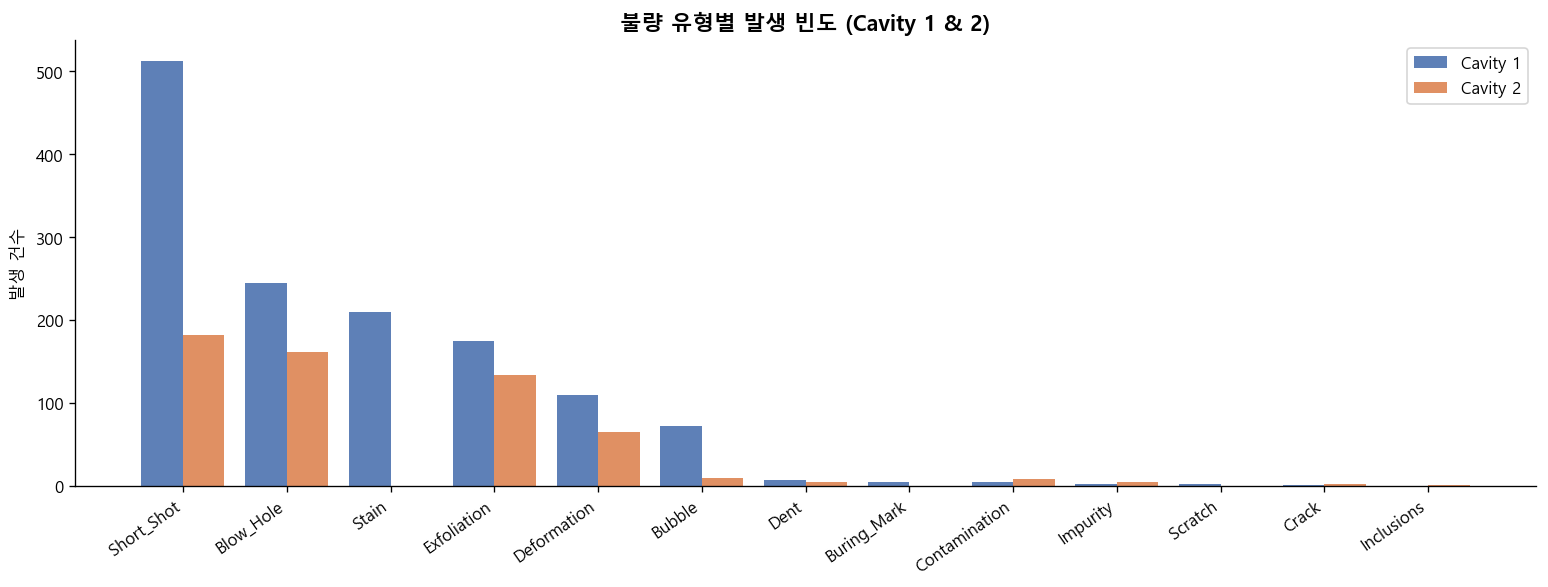


불량 유형별 합계 (Cavity 1 + 2):
Short_Shot       694
Blow_Hole        406
Exfoliation      309
Stain            209
Deformation      174
Bubble            81
Contamination     12
Dent              11
Impurity           7
Buring_Mark        5
Crack              3
Scratch            2
Inclusions         1
dtype: int64


In [8]:
# ── 불량 유형별 빈도 ─────────────────────────────────────────
defect_labels = ['Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain',
                 'Dent','Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions']

counts_1 = {label: df[f'Defects_{label}_1'].sum() for label in defect_labels}
counts_2 = {label: df[f'Defects_{label}_2'].sum() for label in defect_labels}

defect_df = pd.DataFrame({'Cavity_1': counts_1, 'Cavity_2': counts_2}).sort_values('Cavity_1', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(defect_df))
w = 0.4
ax.bar(x - w/2, defect_df['Cavity_1'], width=w, label='Cavity 1', color=PALETTE[0], alpha=0.9)
ax.bar(x + w/2, defect_df['Cavity_2'], width=w, label='Cavity 2', color=PALETTE[1], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(defect_df.index, rotation=35, ha='right')
ax.set_ylabel('발생 건수')
ax.set_title('불량 유형별 발생 빈도 (Cavity 1 & 2)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n불량 유형별 합계 (Cavity 1 + 2):')
print((defect_df['Cavity_1'] + defect_df['Cavity_2']).sort_values(ascending=False))


### 3-3. 불량 유형별 공정변수 분포 비교

> Top 4 불량 유형(Short_Shot, Blow_Hole, Exfoliation, Stain)과 양품 간
> 주요 공정변수 분포를 바이올린 플롯으로 비교합니다.


**(무엇/왜/어떻게)**

- **무엇**: Top 4 불량 유형별 주요 공정변수 분포 시각화 (바이올린 플롯)
- **왜**: "불량 vs 양품" 이분법을 넘어 불량 유형마다 어떤 공정 조건이 다른지 파악하기 위해서. 이 분석은 템플릿 요구사항(불량 유형별 공정변수 비교)을 충족함.
- **어떻게**: 각 Shot에서 발생한 불량 유형을 우선순위(빈도 높은 순)로 라벨링하고, 상위 5개 공정변수에 대해 그룹별 분포를 바이올린 플롯으로 비교.


라벨 분포:
defect_type_label
양품             6107
Short_Shot      670
Blow_Hole       333
Exfoliation     283
Stain           142
Name: count, dtype: int64



 시각화 변수 Top 5: ['Sensor_Melting_Furnace_Temp', 'Process_Casting_Pressure', 'Process_Clamping_Force', 'Process_Rapid_Rise_Time', 'Process_Spray_1_Time']


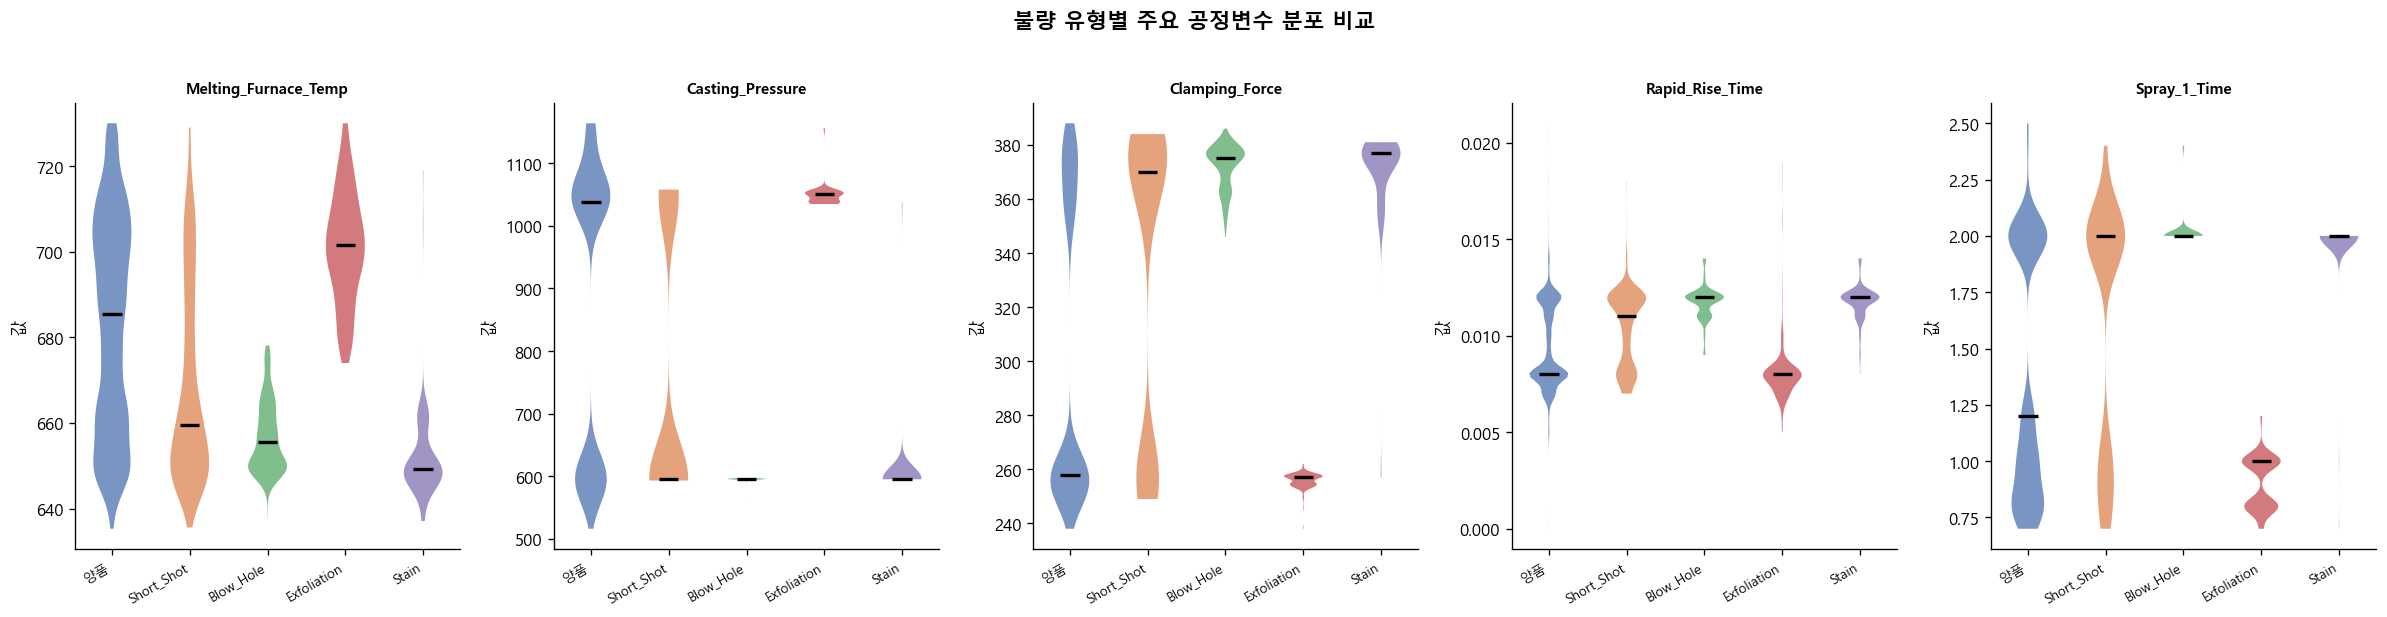


 불량 유형별 ANOVA (F-통계량) - 아래 3-8절에서 상세 분석
  Sensor_Melting_Furnace_Temp                  : F= 247.46, p=0.0000  유의
  Process_Casting_Pressure                     : F= 277.63, p=0.0000  유의
  Process_Clamping_Force                       : F= 306.53, p=0.0000  유의
  Process_Rapid_Rise_Time                      : F= 211.50, p=0.0000  유의
  Process_Spray_1_Time                         : F= 267.40, p=0.0000  유의


In [9]:
# ── 3-3. 불량 유형별 공정변수 분포 비교 ────────────────────────────────────
from scipy import stats

# Top 4 불량 유형 정의 (빈도 기준)
top4_types = ['Short_Shot', 'Blow_Hole', 'Exfoliation', 'Stain']

# 각 Shot에 대해 불량 유형 라벨 생성 (우선순위: 발생 빈도 높은 순)
df['defect_type_label'] = '양품'
for dtype in reversed(top4_types):  # 빈도 낮은 순으로 덮어써야 최종적으로 빈도 높은 게 남음
    col1 = f'Defects_{dtype}_1'
    col2 = f'Defects_{dtype}_2'
    mask = (df.get(col1, 0).astype(float) > 0) | (df.get(col2, 0).astype(float) > 0)
    df.loc[mask, 'defect_type_label'] = dtype

label_order = ['양품'] + top4_types
label_counts = df['defect_type_label'].value_counts()
print('라벨 분포:')
print(label_counts[label_order])

# t-test 기준 상위 5개 변수 선택 (이미 계산된 ttest_df 재사용, 없으면 직접 계산)
# 3-7절 t-test 셀을 먼저 실행했으면 그 결과(ttest_df)를 재사용하고,
# 아직 실행 전이라면 여기서 자체적으로 계산합니다.
_ttest_df = globals().get('ttest_df')  # 변수 존재 여부를 안전하게 확인 (Pylance 경고 방지)
if _ttest_df is not None:
    top5_vars = _ttest_df.head(5)['variable'].tolist()
else:
    from scipy import stats as _st
    _res = []
    for col in process_cols + sensor_cols:
        g = df[df['defect_any']==0][col].dropna()
        b = df[df['defect_any']==1][col].dropna()
        _, p = _st.ttest_ind(g, b, equal_var=False)
        _res.append((col, p))
    top5_vars = [c for c,_ in sorted(_res, key=lambda x:x[1])][:5]

print('\n 시각화 변수 Top 5:', top5_vars)

# ── 바이올린 플롯 ──
fig, axes = plt.subplots(1, len(top5_vars), figsize=(4*len(top5_vars), 5))
palette_v = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

for ax, col in zip(axes, top5_vars):
    data_list  = [df[df['defect_type_label']==lb][col].dropna().values for lb in label_order]
    vp = ax.violinplot(data_list, positions=range(len(label_order)),
                       showmedians=True, showextrema=False)
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(palette_v[i])
        body.set_alpha(0.75)
    vp['cmedians'].set_color('black')
    vp['cmedians'].set_linewidth(2)
    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(label_order, rotation=30, ha='right', fontsize=8)
    ax.set_title(col.replace('Process_','').replace('Sensor_',''), fontsize=9, fontweight='bold')
    ax.set_ylabel('값')

plt.suptitle('불량 유형별 주요 공정변수 분포 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── ANOVA 간이 F-통계량 출력 (불량 유형 간 차이가 유의한지) ──
print('\n 불량 유형별 ANOVA (F-통계량) - 아래 3-8절에서 상세 분석')
for col in top5_vars:
    groups = [df[df['defect_type_label']==lb][col].dropna().values for lb in label_order]
    f, p = stats.f_oneway(*groups)
    sig = '유의' if p < 0.05 else '비유의'
    print(f'  {col:45s}: F={f:7.2f}, p={p:.4f}  {sig}')


### 3-4. 공정 변수 분포 (양품 vs 불량 비교)


**(무엇/왜/어떻게)**

- **무엇**: 주요 공정·센서 변수의 양품 vs 불량 분포 비교 (박스플롯)
- **왜**: 어떤 변수가 양품과 불량을 구분하는 데 시각적으로 유의미한 차이를 보이는지 확인하기 위해서.
- **어떻게**: 양품/불량 그룹으로 나눠 각 변수의 분포를 박스플롯으로 나란히 시각화.


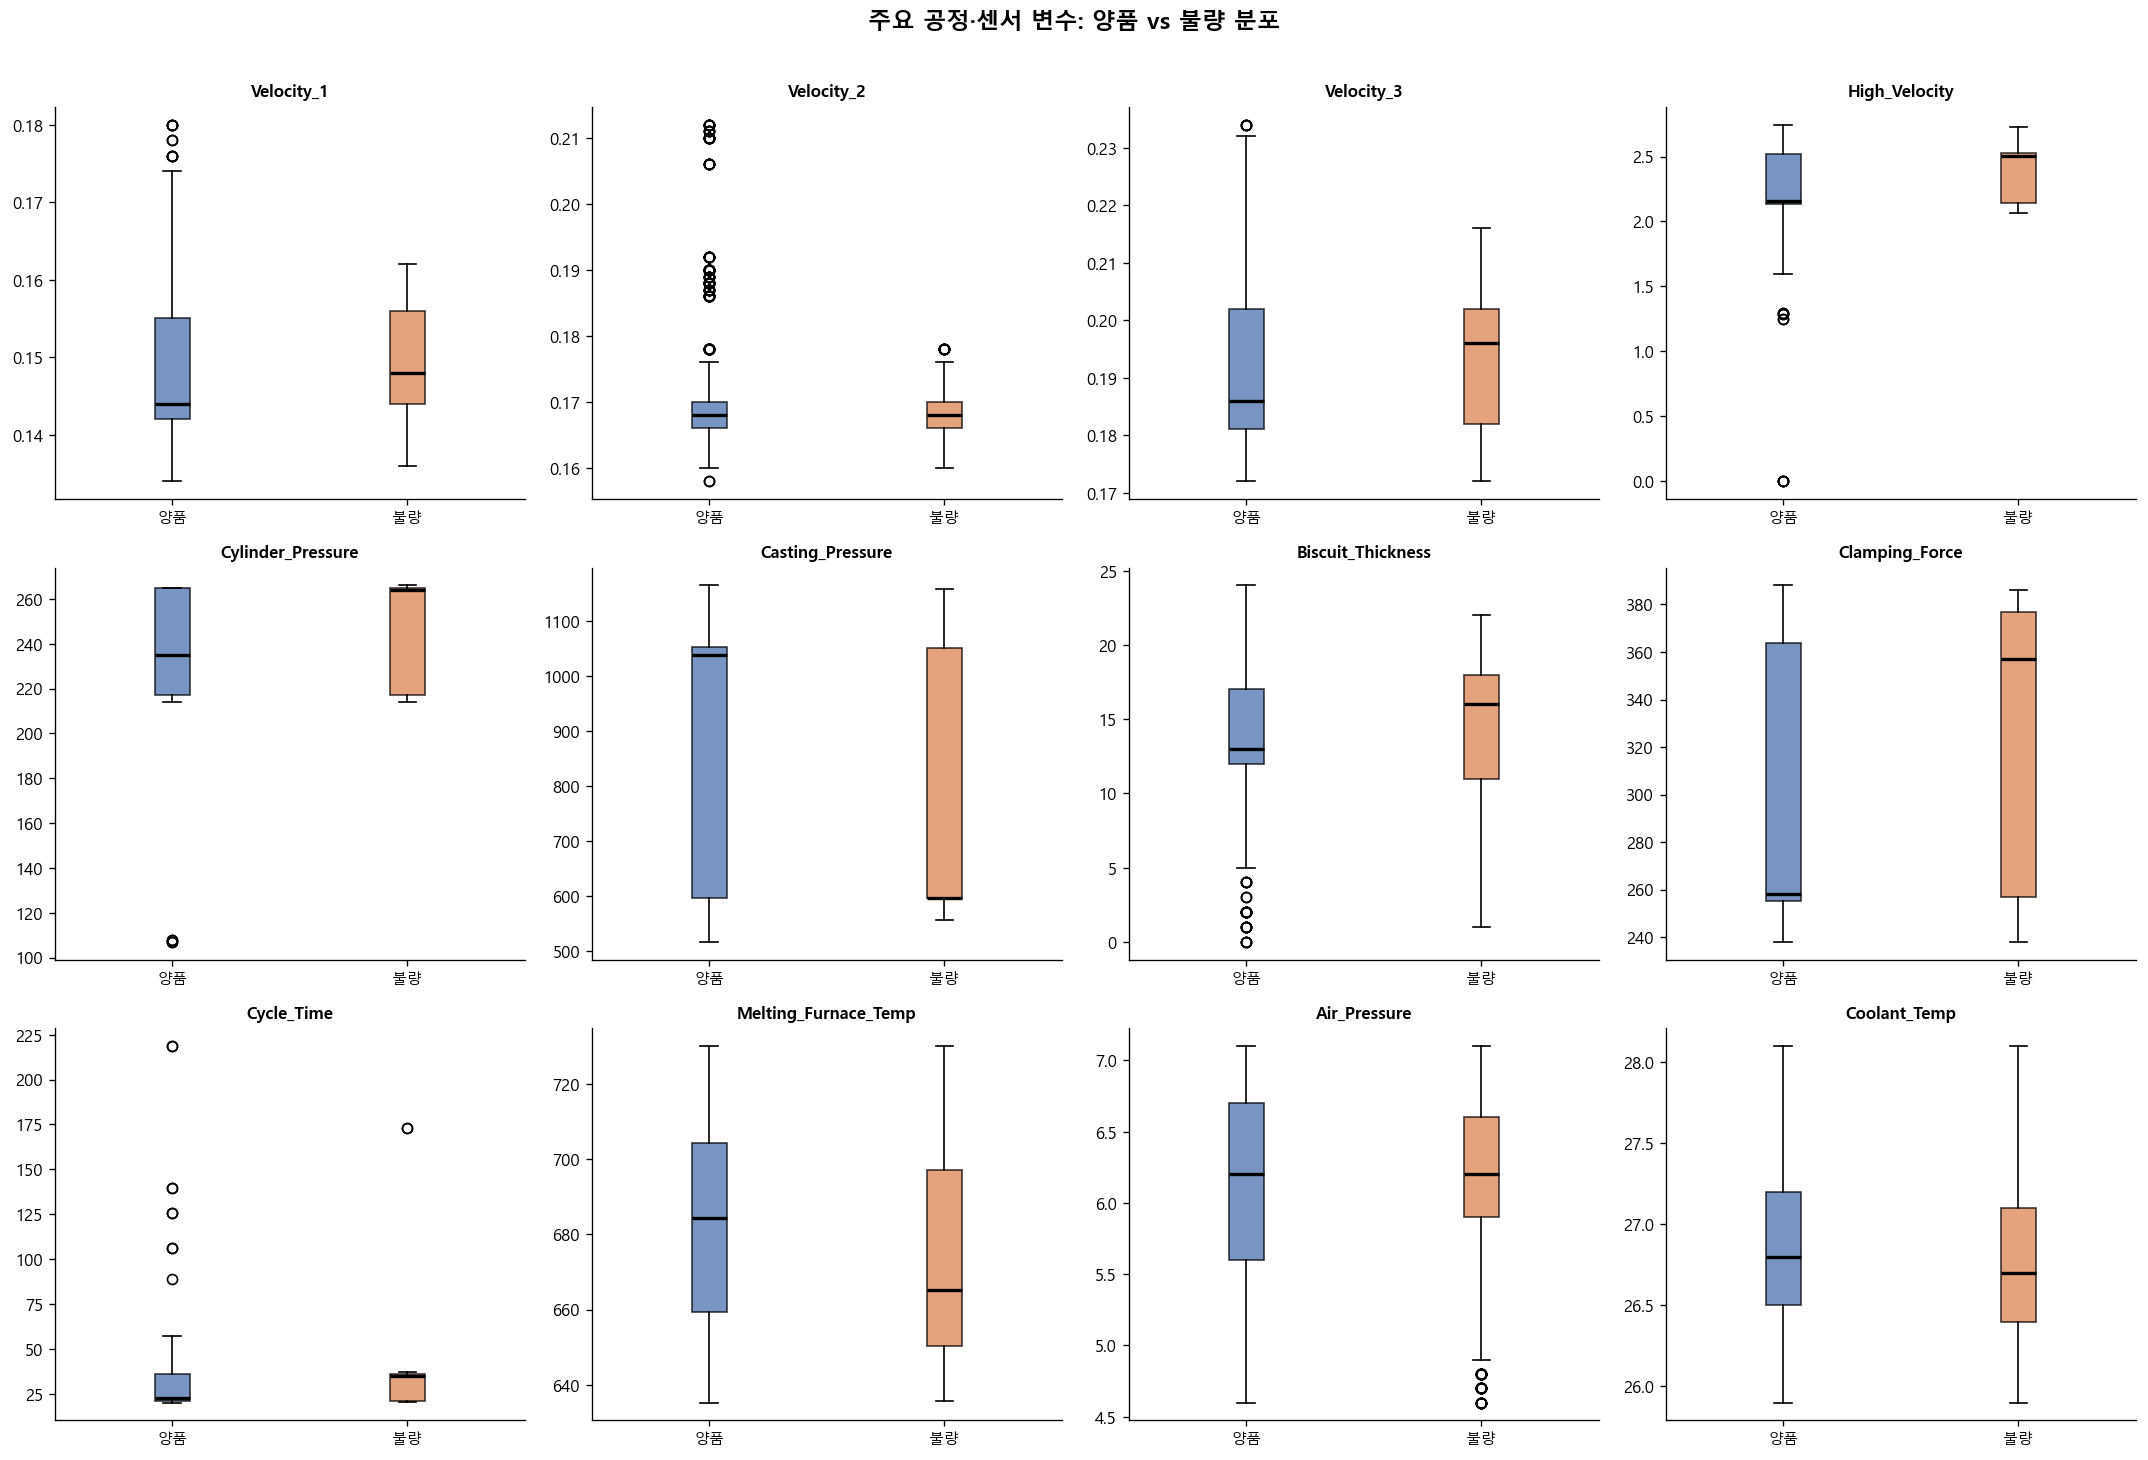

In [10]:
# ── 박스플롯: 주요 공정 변수 양품 vs 불량 ───────────────────
# 데이터 컬럼이 'Process_*'/'Sensor_*'로 구성되어 있고, 원본에 공백이 섞여 있을 수 있어
# 존재하는 컬럼 기준으로 안전하게 매핑.

# (원래 의도한 변수명 → 실제 데이터 컬럼명)
col_map = {
    "Process_Melting_Furnace_Temp": "Sensor_Melting_Furnace_Temp",
    "Process_Coolant_Temp": "Sensor_Coolant_Temp",
    "Process_Air_Pressure": "Sensor_Air_Pressure",
}

key_vars_candidate = [
    'Process_Velocity_1','Process_Velocity_2','Process_Velocity_3',
    'Process_High_Velocity','Process_Cylinder_Pressure',
    'Process_Casting_Pressure','Process_Biscuit_Thickness',
    'Process_Clamping_Force','Process_Cycle_Time',
    # 아래 3개는 데이터상 Sensor_* 로 들어오는 경우가 많음
    'Process_Melting_Furnace_Temp','Process_Air_Pressure','Process_Coolant_Temp'
]

# 실제 존재하는 컬럼으로 정리
key_vars = []
missing = []
for c in key_vars_candidate:
    c2 = col_map.get(c, c)
    if c2 in df.columns:
        key_vars.append(c2)
    else:
        missing.append(c)

# 누락이 있으면 알려주되, 셀은 계속 실행되게 함
if missing:
    print("박스플롯에서 제외된(미존재) 컬럼:", missing)

n = len(key_vars)
rows = (n + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(18, 4*rows))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    data_good = df[df['defect_any'] == 0][col]
    data_bad  = df[df['defect_any'] == 1][col]
    bp = axes[i].boxplot([data_good.dropna(), data_bad.dropna()],
                          labels=['양품', '불량'],
                          patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(PALETTE[0])
    bp['boxes'][1].set_facecolor(PALETTE[1])
    for patch in bp['boxes']:
        patch.set_alpha(0.75)
    short_name = col.replace('Process_','').replace('Sensor_','')
    axes[i].set_title(short_name, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=9)

# 남는 축 비우기
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle('주요 공정·센서 변수: 양품 vs 불량 분포', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3-5. 상관 행렬 (공정 변수)


**(무엇/왜/어떻게)**

- **무엇**: 공정·센서 변수 간, 그리고 불량 타겟(defect_any)과의 상관관계 행렬 시각화
- **왜**: 다중공선성(높은 상관 변수 쌍)을 발견하고, 불량과 가장 관련 높은 변수를 사전에 파악하기 위해서.
- **어떻게**: Pearson 상관계수를 히트맵으로 시각화하고, defect_any 기준 상위 상관 변수를 출력.


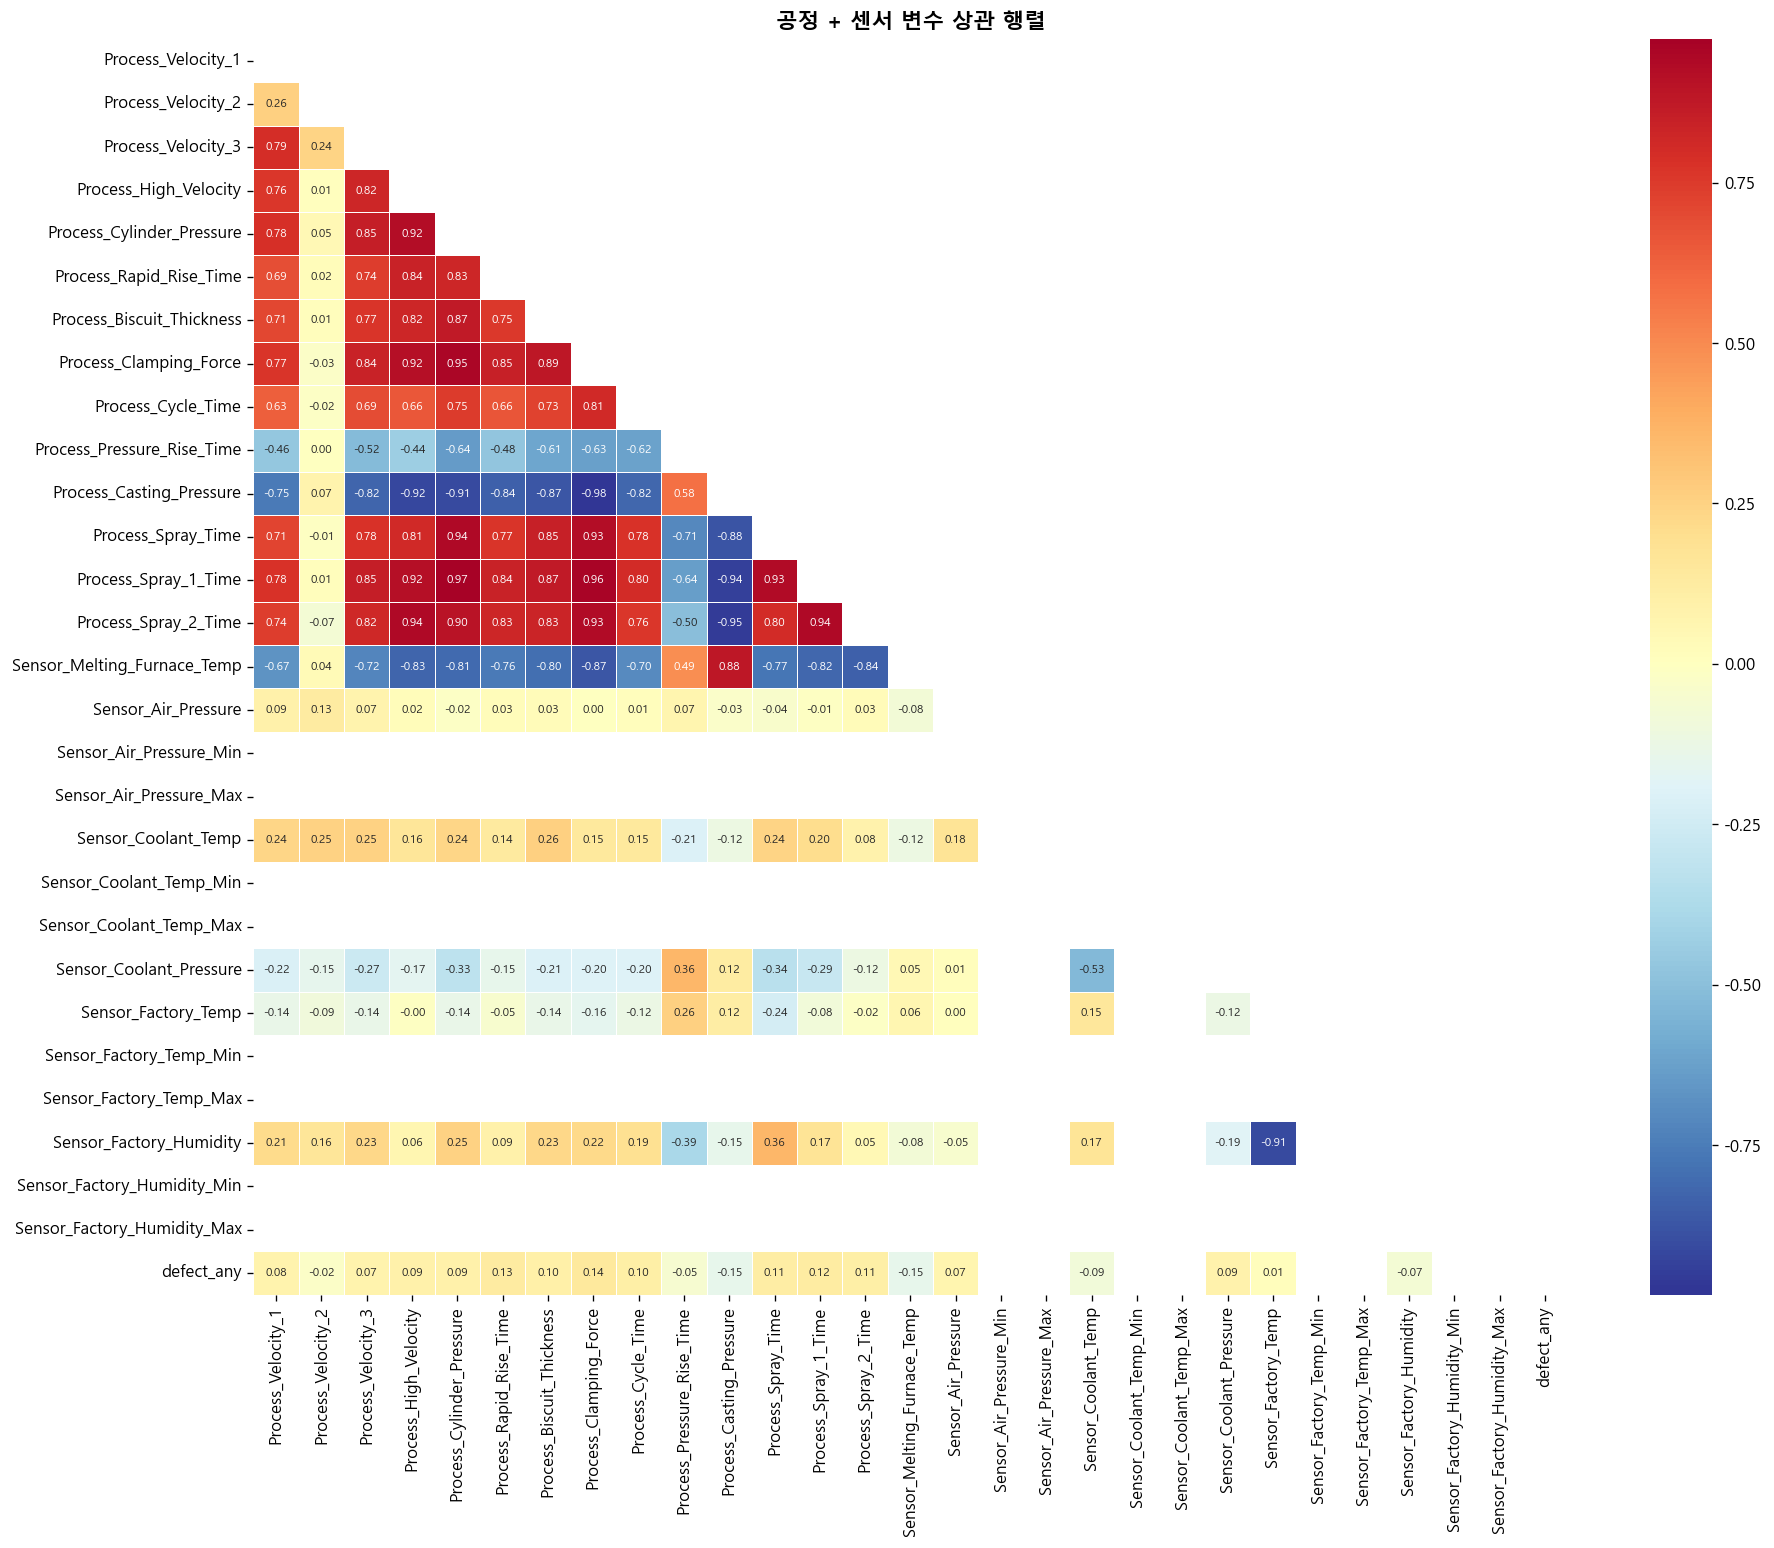


 불량(defect_any)과 상관관계 높은 변수 TOP 10:
Sensor_Melting_Furnace_Temp   0.1456
Process_Casting_Pressure      0.1452
Process_Clamping_Force        0.1428
Process_Rapid_Rise_Time       0.1327
Process_Spray_1_Time          0.1248
Process_Spray_Time            0.1110
Process_Spray_2_Time          0.1062
Process_Cycle_Time            0.1042
Process_Biscuit_Thickness     0.0959
Process_Cylinder_Pressure     0.0932
Name: defect_any, dtype: float64


In [11]:
# ── 상관 행렬 ────────────────────────────────────────────────
corr_df = df[process_cols + sensor_cols + ['defect_any']].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.4, ax=ax,
            annot_kws={'size': 7})
ax.set_title('공정 + 센서 변수 상관 행렬', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# defect_any 상관관계 TOP
print('\n 불량(defect_any)과 상관관계 높은 변수 TOP 10:')
print(corr_df['defect_any'].drop('defect_any').abs().sort_values(ascending=False).head(10))


### 3-6. 이상치 탐색 (IQR 방법)


**(무엇/왜/어떻게)**

- **무엇**: IQR 방법으로 각 변수의 이상치 비율 산출 및 시각화
- **왜**: 이상치가 많은 변수는 모델 학습 시 왜곡을 유발할 수 있어, 전처리 우선순위 결정에 활용하기 위해서.
- **어떻게**: Q1 - 1.5×IQR ~ Q3 + 1.5×IQR 범위를 벗어난 값의 비율을 변수별로 계산.


이상치 비율 TOP 15:
Sensor_Factory_Temp            2.69 %
Process_Velocity_2             2.44 %
Process_Biscuit_Thickness      0.16 %
Process_Cycle_Time             0.15 %
Process_Rapid_Rise_Time        0.13 %
Process_High_Velocity          0.13 %
Process_Velocity_1             0.08 %
Process_Velocity_3             0.05 %
Process_Pressure_Rise_Time     0.05 %
Process_Cylinder_Pressure      0.05 %
Process_Casting_Pressure        0.0 %
Process_Clamping_Force          0.0 %
Process_Spray_Time              0.0 %
Process_Spray_1_Time            0.0 %
Sensor_Melting_Furnace_Temp     0.0 %
dtype: object


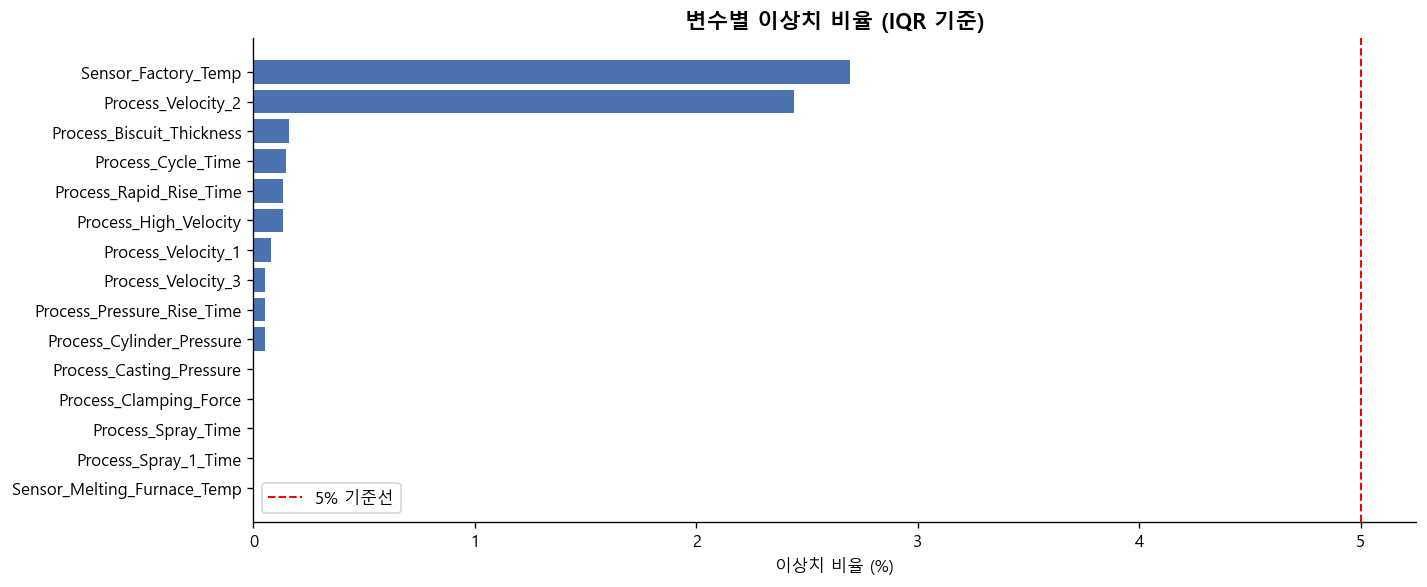

In [12]:
# ── IQR 기반 이상치 비율 ─────────────────────────────────────
def outlier_ratio(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).mean()

outlier_rates = {col: outlier_ratio(df[col]) for col in process_cols + sensor_cols}
outlier_series = pd.Series(outlier_rates).sort_values(ascending=False)

print('이상치 비율 TOP 15:')
print((outlier_series.head(15) * 100).round(2).astype(str) + ' %')

fig, ax = plt.subplots(figsize=(12, 5))
top15 = outlier_series.head(15)
colors = ['#e74c3c' if v > 0.05 else '#4C72B0' for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1] * 100, color=colors[::-1])
ax.axvline(5, color='red', linestyle='--', linewidth=1.2, label='5% 기준선')
ax.set_xlabel('이상치 비율 (%)')
ax.set_title('변수별 이상치 비율 (IQR 기준)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 3-7. 통계 검정: Welch's t-test (양품 vs 불량)


**(무엇/왜/어떻게)**

- **무엇**: Welch's t-test로 양품·불량 그룹 간 각 변수의 평균 차이가 통계적으로 유의한지 검정
- **왜**: 시각적 차이가 실제로 유의미한지 통계적으로 확인하고, 유의한 변수만 분석에 집중하기 위해서.
- **어떻게**: 불균형·샘플 수 차이를 고려해 등분산 가정 없는 Welch's t-test 적용 후 p-value 기준 정렬.


In [13]:
# ── Welch's t-test ────────────────────────────────────────────
# welch's t-test를 사용한 이유 - 지금 데이터는 불균형이며, 샘플 수 차이가 크기 때문임
from scipy import stats

results = []
good_mask = df['defect_any'] == 0
bad_mask  = df['defect_any'] == 1

for col in process_cols + sensor_cols:
    g = df.loc[good_mask, col].dropna()
    b = df.loc[bad_mask,  col].dropna()
    t_stat, p_val = stats.ttest_ind(g, b, equal_var=False)
    results.append({
        'variable': col,
        'mean_good': g.mean(),
        'mean_bad':  b.mean(),
        'diff':      b.mean() - g.mean(),
        't_stat':    t_stat,
        'p_value':   p_val,
        'significant': '유의' if p_val < 0.05 else '비유의'
    })

ttest_df = pd.DataFrame(results).sort_values('p_value')
print('유의한 변수 (p < 0.05):')
sig = ttest_df[ttest_df['significant'] == '유의']
print(sig[['variable','mean_good','mean_bad','diff','p_value']].to_string(index=False))


유의한 변수 (p < 0.05):
                   variable  mean_good  mean_bad     diff  p_value
Sensor_Melting_Furnace_Temp   682.6312  673.8044  -8.8268   0.0000
   Process_Casting_Pressure   875.2633  793.5376 -81.7257   0.0000
     Process_Clamping_Force   302.0364  321.6519  19.6154   0.0000
    Process_Rapid_Rise_Time     0.0094    0.0101   0.0007   0.0000
       Process_Spray_1_Time     1.3717    1.5385   0.1668   0.0000
       Process_Spray_2_Time     1.3552    1.5375   0.1823   0.0000
         Process_Spray_Time     9.7061   10.1964   0.4903   0.0000
         Process_Cycle_Time    27.2477   29.4259   2.1782   0.0000
      Process_High_Velocity     2.3081    2.3577   0.0496   0.0000
  Process_Biscuit_Thickness    14.1403   14.8958   0.7555   0.0000
    Sensor_Coolant_Pressure     2.6987    2.7095   0.0107   0.0000
  Process_Cylinder_Pressure   238.4880  243.6969   5.2088   0.0000
        Sensor_Coolant_Temp    26.8543   26.7465  -0.1077   0.0000
         Process_Velocity_1     0.1479    0

### 3-8. ANOVA 분석 (불량 유형별 공정변수 차이 검정)

> Welch's t-test가 이진(양품/불량) 비교라면, **One-Way ANOVA**는 불량 유형이 3개 이상일 때  
> 각 그룹 간 평균 차이가 통계적으로 유의한지 동시에 검정합니다.  
> 유의한 변수에 대해 **Tukey HSD 사후검정**으로 어떤 유형 쌍이 다른지 추가 확인합니다.


**(무엇/왜/어떻게)**

- **무엇**: One-Way ANOVA + Tukey HSD 사후검정으로 불량 유형별 공정변수 평균 차이 검정
- **왜**: t-test는 두 그룹 비교이므로, 양품/Short_Shot/Blow_Hole/Exfoliation/Stain 5개 그룹 동시 비교에는 ANOVA가 적합. 템플릿 요구사항(ANOVA 분석) 충족.
- **어떻게**: scipy f_oneway로 F-통계량 계산, 유의한 변수에 statsmodels Tukey HSD 적용.


One-Way ANOVA 결과 (p < 0.05 기준)
                   variable   F_stat  p_value
     Process_Clamping_Force 306.5277   0.0000
         Process_Spray_Time 301.1014   0.0000
   Process_Casting_Pressure 277.6327   0.0000
  Process_Cylinder_Pressure 270.6949   0.0000
       Process_Spray_1_Time 267.3997   0.0000
Sensor_Melting_Furnace_Temp 247.4616   0.0000
  Process_Biscuit_Thickness 221.7081   0.0000
    Process_Rapid_Rise_Time 211.5011   0.0000
       Process_Spray_2_Time 209.3130   0.0000
      Process_High_Velocity 186.3503   0.0000
         Process_Velocity_3 181.6147   0.0000
         Process_Cycle_Time 175.0721   0.0000
         Process_Velocity_1 152.6806   0.0000
 Process_Pressure_Rise_Time 138.6058   0.0000
    Sensor_Coolant_Pressure  46.4999   0.0000
        Sensor_Factory_Temp  45.9591   0.0000
    Sensor_Factory_Humidity  38.7480   0.0000
        Sensor_Coolant_Temp  36.4240   0.0000
        Sensor_Air_Pressure  12.1695   0.0000
         Process_Velocity_2   2.6999   0.0290

→ 

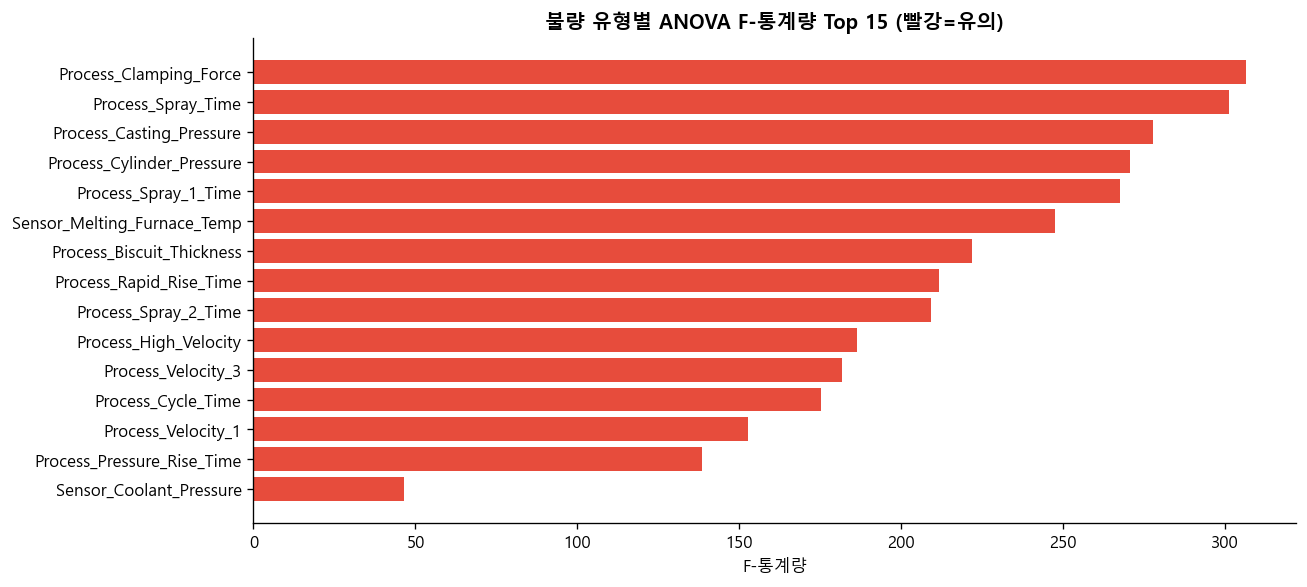

In [14]:
# ── 3-8. ANOVA 분석 ───────────────────────────────────────────────────────
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 불량 유형 라벨 (3-3에서 생성된 defect_type_label 재사용)
if 'defect_type_label' not in df.columns:
    top4_types = ['Short_Shot', 'Blow_Hole', 'Exfoliation', 'Stain']
    df['defect_type_label'] = '양품'
    for dtype in reversed(top4_types):
        mask = (df.get(f'Defects_{dtype}_1', 0).astype(float) > 0) | \
               (df.get(f'Defects_{dtype}_2', 0).astype(float) > 0)
        df.loc[mask, 'defect_type_label'] = dtype

label_order = ['양품', 'Short_Shot', 'Blow_Hole', 'Exfoliation', 'Stain']
groups_df   = df[df['defect_type_label'].isin(label_order)]

# ── One-Way ANOVA: 모든 공정·센서 변수 ──────────────────────────
anova_results = []
for col in process_cols + sensor_cols:
    grp_data = [groups_df[groups_df['defect_type_label']==lb][col].dropna().values
                for lb in label_order]
    # 샘플 수 2 이상인 그룹만 포함
    grp_data = [g for g in grp_data if len(g) >= 2]
    if len(grp_data) < 2:
        continue
    f_stat, p_val = stats.f_oneway(*grp_data)
    anova_results.append({'variable': col, 'F_stat': f_stat, 'p_value': p_val,
                          'significant': '★ 유의' if p_val < 0.05 else '비유의'})

anova_df = pd.DataFrame(anova_results).sort_values('p_value')
print('=' * 60)
print('One-Way ANOVA 결과 (p < 0.05 기준)')
print('=' * 60)
sig_anova = anova_df[anova_df['significant'] == '★ 유의']
print(sig_anova[['variable','F_stat','p_value']].to_string(index=False))
print(f'\n→ 유의한 변수: {len(sig_anova)}개 / 전체 {len(anova_df)}개')

# ── Tukey HSD 사후검정: F-통계량 TOP 5 변수 ──────────────────────
top5_anova = anova_df.head(5)['variable'].tolist()
print('\n' + '=' * 60)
print('Tukey HSD 사후검정 (Top 5 변수)')
print('=' * 60)

for col in top5_anova:
    sub = groups_df[['defect_type_label', col]].dropna()
    try:
        tukey = pairwise_tukeyhsd(endog=sub[col], groups=sub['defect_type_label'], alpha=0.05)
        sig_pairs = [(r[0], r[1]) for r in tukey.summary().data[1:] if r[5] == True]  # reject=True
        print(f'\n[{col}]')
        print(f'  유의한 쌍 ({len(sig_pairs)}개): {sig_pairs}')
    except Exception as e:
        print(f'\n[{col}] Tukey 계산 실패: {e}')

# ── ANOVA F-통계량 상위 15 시각화 ────────────────────────────────
top15_anova = anova_df.head(15)
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e74c3c' if p < 0.05 else '#4C72B0' for p in top15_anova['p_value']]
ax.barh(top15_anova['variable'][::-1], top15_anova['F_stat'][::-1], color=colors[::-1])
ax.set_xlabel('F-통계량')
ax.set_title('불량 유형별 ANOVA F-통계량 Top 15 (빨강=유의)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 4️. 데이터 전처리

**(무엇/왜/어떻게)**

- **무엇**: 모델 입력 피처(X)와 타겟(y) 정의, 분산=0인 무의미한 컬럼 자동 제거
- **왜**: 고정값(분산=0) 컬럼은 모델에 아무 정보를 주지 않으므로 제거해 불필요한 차원을 줄이기 위해서.
- **어떻게**: Process/Sensor 컬럼을 피처로 설정하고, `std()==0`인 컬럼을 자동 탐지해 제거.


In [15]:
# ── 피처 & 타겟 정의 ─────────────────────────────────────────
# Process_Product_Type(제품 유형)을 피처에 포함
# → Type1(불량률 17.6%) vs Type2(불량률 28.5%)로 불량률 차이가 1.6배이므로 예측에 유의미
feature_cols = process_cols + sensor_cols + ['Process_Product_Type']

# Process_Product_Type을 숫자형으로 변환 (1 또는 2로 이미 인코딩됨)
df['Process_Product_Type'] = pd.to_numeric(df['Process_Product_Type'], errors='coerce')

X = df[feature_cols].copy()
y = df['defect_any'].copy()

# ── 분산=0 컬럼 제거 (모델에 정보를 주지 않는 고정값 컬럼) ──────
# 예: Sensor_Air_Pressure_Min/Max, Sensor_Coolant_Temp_Min/Max 등 8개
zero_var_cols = X.columns[X.std() == 0].tolist()
if zero_var_cols:
    X = X.drop(columns=zero_var_cols)
    feature_cols = X.columns.tolist()
    print(f'분산=0 컬럼 제거 ({len(zero_var_cols)}개): {zero_var_cols}')
else:
    print('분산=0 컬럼 없음')

print(f'\nFeature shape : {X.shape}')
print(f'피처 목록: {feature_cols}')
print(f'\nTarget 분포:\n{y.value_counts()}')


분산=0 컬럼 제거 (8개): ['Sensor_Air_Pressure_Min', 'Sensor_Air_Pressure_Max', 'Sensor_Coolant_Temp_Min', 'Sensor_Coolant_Temp_Max', 'Sensor_Factory_Temp_Min', 'Sensor_Factory_Temp_Max', 'Sensor_Factory_Humidity_Min', 'Sensor_Factory_Humidity_Max']

Feature shape : (7535, 21)
피처 목록: ['Process_Velocity_1', 'Process_Velocity_2', 'Process_Velocity_3', 'Process_High_Velocity', 'Process_Cylinder_Pressure', 'Process_Rapid_Rise_Time', 'Process_Biscuit_Thickness', 'Process_Clamping_Force', 'Process_Cycle_Time', 'Process_Pressure_Rise_Time', 'Process_Casting_Pressure', 'Process_Spray_Time', 'Process_Spray_1_Time', 'Process_Spray_2_Time', 'Sensor_Melting_Furnace_Temp', 'Sensor_Air_Pressure', 'Sensor_Coolant_Temp', 'Sensor_Coolant_Pressure', 'Sensor_Factory_Temp', 'Sensor_Factory_Humidity', 'Process_Product_Type']

Target 분포:
defect_any
0    5846
1    1689
Name: count, dtype: int64


### 4-2. VIF 다중공선성 분석

> VIF(Variance Inflation Factor)가 10 이상이면 다중공선성이 심각한 수준입니다.  
> XGBoost는 다중공선성에 비교적 강하지만, **SHAP 해석 시 중요도가 분산**되어 "실제 원인 변수"가 흐려질 수 있습니다.  
> 분석 결과를 참고하여 모델링 시 유의합니다.


**(무엇/왜/어떻게)**

- **무엇**: VIF 계산으로 다중공선성 심각도 측정 + 상관계수 0.9 이상 변수 쌍 목록 출력
- **왜**: 이 데이터는 Process_Product_Type이 Clamping_Force, Casting_Pressure 등과 r≥0.99로 묶임. 이런 변수들이 모두 피처에 있으면 SHAP 중요도가 분산되어 해석이 왜곡될 수 있음.
- **어떻게**: statsmodels variance_inflation_factor로 VIF 산출 후, VIF>10인 변수를 하이라이트.


VIF 분석 결과 (VIF > 10 = 다중공선성 문제)
                    feature        VIF
  Process_Cylinder_Pressure 90074.2596
       Process_Product_Type 73428.3212
   Process_Casting_Pressure 48045.5825
        Sensor_Coolant_Temp  7423.5132
        Sensor_Factory_Temp  7386.3064
    Sensor_Coolant_Pressure  5343.1725
Sensor_Melting_Furnace_Temp  3771.7586
     Process_Clamping_Force  2891.1060
      Process_High_Velocity  2705.8901
         Process_Velocity_2  2235.1220
    Sensor_Factory_Humidity  1681.3709
         Process_Velocity_3  1528.7077
         Process_Velocity_1  1513.2487
         Process_Spray_Time   985.5083
       Process_Spray_1_Time   482.9719
 Process_Pressure_Rise_Time   277.0330
       Process_Spray_2_Time   240.5629
        Sensor_Air_Pressure   113.8010
  Process_Biscuit_Thickness   109.7418
    Process_Rapid_Rise_Time    83.5165
         Process_Cycle_Time    52.4095

 VIF > 10 변수: 21개
['Process_Cylinder_Pressure', 'Process_Product_Type', 'Process_Casting_Pressure', 'Sensor_C

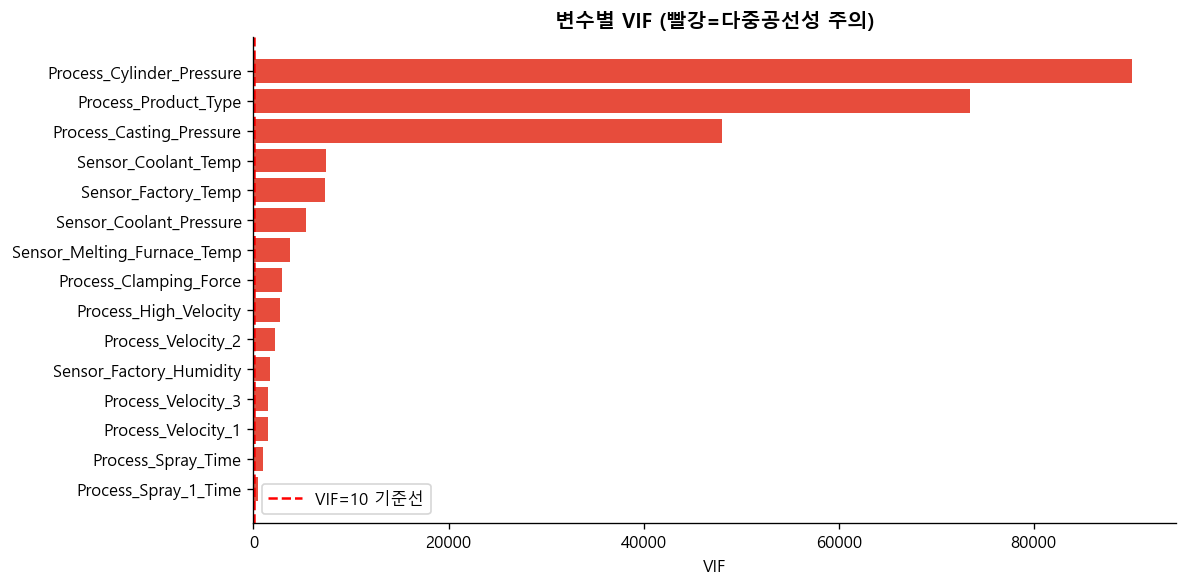


 해석: XGBoost는 다중공선성에 비교적 강하나, SHAP 해석 시 중요도가
   유사 변수 간 분산될 수 있습니다. 결과 해석 시 참고하세요.


In [16]:
# ── 4-2. VIF 다중공선성 분석 ─────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer

# VIF 계산용 임시 결측치 처리 (중앙값)
_imp = SimpleImputer(strategy='median')
X_vif = pd.DataFrame(_imp.fit_transform(X), columns=X.columns)

vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('=' * 55)
print('VIF 분석 결과 (VIF > 10 = 다중공선성 문제)')
print('=' * 55)
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]
print(f'\n VIF > 10 변수: {len(high_vif)}개')
print(high_vif['feature'].tolist())

# ── 상관계수 0.9 이상 변수 쌍 ────────────────────────────────────
corr_abs = X_vif.corr().abs()
high_corr_pairs = []
for i in range(len(corr_abs.columns)):
    for j in range(i+1, len(corr_abs.columns)):
        val = corr_abs.iloc[i, j]
        if val >= 0.9:
            high_corr_pairs.append((corr_abs.columns[i], corr_abs.columns[j], round(val, 3)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['변수A', '변수B', '상관계수'])\
                 .sort_values('상관계수', ascending=False)
print(f'\n 상관계수 ≥ 0.9 변수 쌍: {len(high_corr_df)}개')
print(high_corr_df.to_string(index=False))

# ── 시각화: VIF TOP 15 ───────────────────────────────────────────
top15_vif = vif_data.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 10 else '#4C72B0' for v in top15_vif['VIF']]
ax.barh(top15_vif['feature'][::-1], top15_vif['VIF'][::-1], color=colors[::-1])
ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='VIF=10 기준선')
ax.set_xlabel('VIF')
ax.set_title('변수별 VIF (빨강=다중공선성 주의)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n 해석: XGBoost는 다중공선성에 비교적 강하나, SHAP 해석 시 중요도가')
print('   유사 변수 간 분산될 수 있습니다. 결과 해석 시 참고하세요.')


**(무엇/왜/어떻게)**

- **무엇**: 결측치 처리 (중앙값 대체)
- **왜**: 불균형 데이터에서 이상치가 존재할 가능성이 있으므로, 이상치에 영향을 받는 평균 대신 중앙값으로 대체하는 것이 더 안정적임. 특히 센서 오류로 인한 결측치가 의심되는 제조 데이터에 적합한 방법.
- **어떻게**: `SimpleImputer(strategy='median')`으로 각 컬럼의 결측치를 해당 컬럼 중앙값으로 일괄 대체.


In [17]:
# ── 결측치 처리 (중앙값 대체) ────────────────────────────────
# 중앙값으로 대체한 이유 - 불균형 데이터 -> 이상치 존재 가능성이 있음(예를 들면 제조 데이터에서의 센서 오류?) -> 고로 평균보다 중앙값이 합리적이라 판단했음.
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

print('결측치 처리 후:', X_imp.isnull().sum().sum(), '개')


결측치 처리 후: 0 개


**(무엇/왜/어떻게)**

- **무엇**: 이상치 완화(IQR 클리핑)
- **왜**: 극단값이 모델을 과하게 흔드는 것을 줄여 안정적인 학습을 도움.
- **어떻게**: IQR 범위 기반 상·하한을 계산하고, 그 밖의 값은 경계값으로 잘라냄.


In [18]:
# ── IQR 클리핑 (이상치 처리) ─────────────────────────────────
def clip_iqr(df_in, factor=3.0):
    df_out = df_in.copy()
    for col in df_out.columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        df_out[col] = df_out[col].clip(Q1 - factor*IQR, Q3 + factor*IQR)
    return df_out

X_clipped = clip_iqr(X_imp, factor=3.0)
print('IQR 클리핑 완료 (factor=3.0)')


IQR 클리핑 완료 (factor=3.0)


**(무엇/왜/어떻게)***

- **무엇**: 학습/테스트 데이터 분할
- **왜**: 학습에 사용하지 않은 데이터로 성능을 평가해야 실제 적용 성능을 추정할 수 있음.
- **어떻게**: 불량 비율을 유지(stratify)한 채로 8:2로 나눔.


In [19]:
# ── 학습 / 테스트 분할 ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_clipped, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train 불량률: {y_train.mean()*100:.1f}%  |  Test 불량률: {y_test.mean()*100:.1f}%')


Train: (6028, 21)  |  Test: (1507, 21)
Train 불량률: 22.4%  |  Test 불량률: 22.4%


## 5️. 머신러닝 모델 학습 & 평가


### 5-1. 베이스라인 모델 비교 (RandomForest / LightGBM / XGBoost)

> 최종 모델(XGBoost) 선정의 근거를 마련하기 위해 세 가지 모델을 5-Fold CV로 비교합니다.  
> 평가 지표: ROC-AUC, PR-AUC, F1, Recall (불량 클래스 중심)


**(무엇/왜/어떻게)**

- **무엇**: RandomForest, LightGBM, XGBoost 세 모델을 동일 조건(SMOTE + 5-Fold CV)으로 비교
- **왜**: 단일 모델만 쓰면 "왜 이 모델인가"에 대한 근거가 없음. 템플릿 요구사항(RF, XGBoost, LightGBM 비교 + 최적 모델 선택)을 충족하기 위해서.
- **어떻게**: imblearn Pipeline으로 SMOTE Leak-free 적용, StratifiedKFold 5-fold CV, 결과를 표와 막대 그래프로 비교.


베이스라인 모델 5-Fold CV 비교 (Train set)


,roc_auc,pr_auc,f1,recall,precision
모델,,,,,
RandomForest,0.7908 ± 0.0077,0.5135 ± 0.0202,0.5389 ± 0.0057,0.6558 ± 0.0125,0.4577 ± 0.0122
LightGBM,0.8497 ± 0.0055,0.6413 ± 0.0179,0.6173 ± 0.0116,0.7461 ± 0.0299,0.5270 ± 0.0108
XGBoost,0.8319 ± 0.0048,0.6138 ± 0.0235,0.5392 ± 0.0333,0.4737 ± 0.0392,0.6279 ± 0.0370


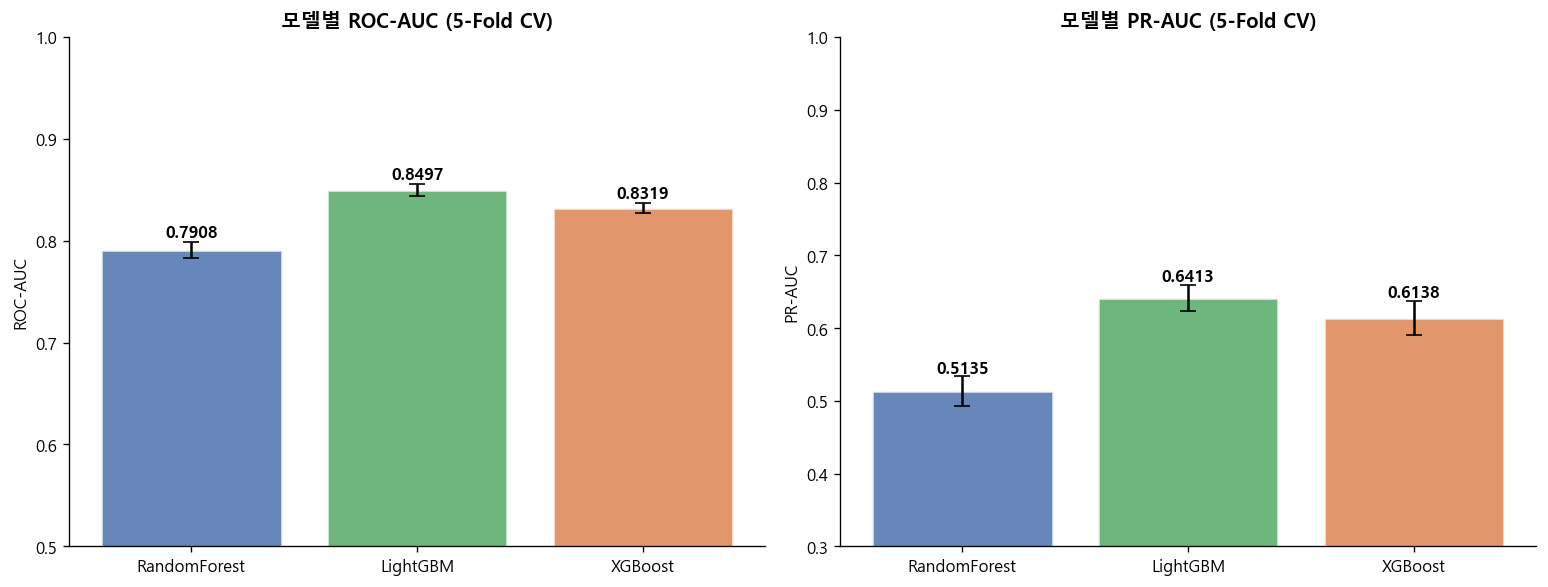


 ROC-AUC 기준 최고 성능 모델: [LightGBM]
→ 이후 5-2절에서 XGBoost를 최종 모델로 사용합니다.
  (XGBoost: 성능 우수 + SHAP TreeExplainer 지원 + Calibration 가능)


In [20]:
# ── 5-1. 베이스라인 모델 비교 ────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier
from lightgbm                import LGBMClassifier
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE

# feature matrix 확인
if 'X_clipped' in globals():
    X_ = X_clipped.copy()
elif 'X' in globals():
    X_ = X.copy()
else:
    raise NameError("X_clipped 또는 X 변수가 없습니다. 전처리 셀을 먼저 실행하세요.")

if all(k in globals() for k in ['X_train','X_test','y_train','y_test']):
    X_tr_, y_tr_ = X_train, y_train
else:
    from sklearn.model_selection import train_test_split
    X_tr_, _, y_tr_, _ = train_test_split(X_, df['defect_any'], test_size=0.2,
                                           random_state=42, stratify=df['defect_any'])

# ── 스케일링 참고 사항 ──────────────────────────────────────────────
# RandomForest / LightGBM / XGBoost 모두 트리 계열로 피처 스케일에 무관하므로
# StandardScaler 없이 직접 비교해도 공정성이 유지됨.
# ※ 향후 LogisticRegression, SVM 등 거리 기반 모델을 추가할 경우,
#   Pipeline에 StandardScaler()를 반드시 포함해야 공정한 비교가 됨.

# ── 모델 정의 ────────────────────────────────────────────────────
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        num_leaves=31, subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=(y_tr_==0).sum()/(y_tr_==1).sum(),
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.9, colsample_bytree=0.9,
        random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'roc_auc':'roc_auc', 'pr_auc':'average_precision',
           'f1':'f1', 'recall':'recall', 'precision':'precision'}

results = {}
for name, model in models.items():
    pipe = ImbPipeline([('smote', SMOTE(random_state=42)), ('model', model)])
    cv_res = cross_validate(pipe, X_tr_, y_tr_, cv=cv, scoring=scoring,
                            n_jobs=-1, return_train_score=False)
    results[name] = {k.replace('test_',''): (np.mean(v), np.std(v))
                     for k, v in cv_res.items() if k.startswith('test_')}

# ── 결과 테이블 ──────────────────────────────────────────────────
rows = []
for name, metrics in results.items():
    row = {'모델': name}
    for metric, (mean, std) in metrics.items():
        row[metric] = f'{mean:.4f} ± {std:.4f}'
    rows.append(row)

result_df = pd.DataFrame(rows).set_index('모델')
print('=' * 70)
print('베이스라인 모델 5-Fold CV 비교 (Train set)')
print('=' * 70)
display(result_df)

# ── ROC-AUC 막대 그래프 ──────────────────────────────────────────
means  = [results[m]['roc_auc'][0] for m in models]
stds   = [results[m]['roc_auc'][1] for m in models]
colors = ['#4C72B0', '#55A868', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(list(models.keys()), means, yerr=stds, color=colors,
            capsize=5, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('모델별 ROC-AUC (5-Fold CV)', fontweight='bold')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.005, f'{m:.4f}', ha='center', fontsize=10, fontweight='bold')

# PR-AUC
pr_means = [results[m]['pr_auc'][0] for m in models]
pr_stds  = [results[m]['pr_auc'][1] for m in models]
axes[1].bar(list(models.keys()), pr_means, yerr=pr_stds, color=colors,
            capsize=5, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0.3, 1.0)
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('모델별 PR-AUC (5-Fold CV)', fontweight='bold')
for i, (m, s) in enumerate(zip(pr_means, pr_stds)):
    axes[1].text(i, m + s + 0.005, f'{m:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ── 최적 모델 선정 근거 ──────────────────────────────────────────
best_model_name = max(results, key=lambda m: results[m]['roc_auc'][0])
print(f'\n ROC-AUC 기준 최고 성능 모델: [{best_model_name}]')
print('→ 이후 5-2절에서 XGBoost를 최종 모델로 사용합니다.')
print('  (XGBoost: 성능 우수 + SHAP TreeExplainer 지원 + Calibration 가능)')


### 5-2. Binary 최종 모델 (Leak-free CV · Calibration · 비용 기반 Threshold)

> SMOTE를 CV 폴드 내부에서만 적용하여 데이터 누수를 방지하고,  
> 비용 기반 threshold 최적화로 불량 미탐지(FN)를 최소화합니다.


**(무엇/왜/어떻게)**

- **무엇**: Leak-free SMOTE Pipeline + XGBoost로 이진 분류 모델 학습, Calibration, 비용 기반 Threshold 최적화
- **왜**: 불량 미탐지(FN) 비용이 과탐지(FP)보다 크므로, 단순 정확도 대신 비용 최소화 관점으로 threshold를 최적화하기 위해서.
- **어떻게**: SMOTE를 CV fold 내부에만 적용(누수 방지), CalibratedClassifierCV로 확률 보정, PR 곡선 기반 최적 threshold 탐색.


In [ ]:

# ============================================================
# STEP 1) Binary 모델 완성도 강화
#   - Leak-free CV: SMOTE를 CV fold 내부에서만 적용 (imblearn Pipeline)
#   - 지표: ROC-AUC + PR-AUC + (정밀도/재현율/F1) + Calibration
#   - 비용 기반 threshold: FN 비용이 FP보다 큰 상황 가정하여 최적 threshold 탐색
# ============================================================

import numpy as np
import pandas as pd

# --- (안전) 기존 노트북 변수 재사용, 없으면 로드/구성 ---
if 'df' not in globals():
    raise NameError("df 변수가 없습니다. 위쪽 셀에서 데이터 로드/전처리를 먼저 실행하세요.")
if 'defect_any' not in df.columns:
    raise KeyError("df에 defect_any 컬럼이 없습니다. 위쪽 셀에서 defect_any 생성 셀을 먼저 실행하세요.")

# --- feature matrix 생성/재사용 (STEP1에서 X를 확정합니다) ---
# 우선순위: (1) X_clipped가 있으면 사용 (2) X가 있으면 사용 (3) df에서 자동 생성
if "X_clipped" in globals():
    X = X_clipped.copy()
elif "X" in globals():
    X = X.copy()
else:
    drop_cols = [c for c in df.columns if c.startswith('Defects_')] + ['defect_any']
    candidate = df.drop(columns=drop_cols, errors='ignore')
    X = candidate.select_dtypes(include=[np.number]).copy()

y_bin = df['defect_any'].astype(int).values

# --- train/test split (기존 변수가 있으면 그대로 재사용) ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
if all(k in globals() for k in ['X_train','X_test','y_train','y_test']):
    X_train_, X_test_, y_train_, y_test_ = X_train, X_test, y_train, y_test
else:
    X_train_, X_test_, y_train_, y_test_ = train_test_split(
        X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
    )

# --- Leak-free Pipeline: SMOTE inside CV ---
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             precision_recall_curve, brier_score_loss)
from sklearn.calibration import CalibratedClassifierCV

xgb_bin = XGBClassifier(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

pipe_bin = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", xgb_bin)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

cv_res = cross_validate(pipe_bin, X_train_, y_train_, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
print("Leak-free CV 성능(Train only)")
for k, v in cv_res.items():
    if k.startswith("test_"):
        metric = k.replace("test_", "")
        print(f"- {metric:10s}: {np.mean(v):.4f} ± {np.std(v):.4f}")

# --- Fit final model on full train (with SMOTE) ---
pipe_bin.fit(X_train_, y_train_)
proba_test = pipe_bin.predict_proba(X_test_)[:, 1]

print("\n Test 성능")
print(f"- ROC-AUC : {roc_auc_score(y_test_, proba_test):.4f}")
print(f"- PR-AUC  : {average_precision_score(y_test_, proba_test):.4f}")

# --- Calibration (확률 신뢰도) ---
# CalibratedClassifierCV는 내부적으로 CV를 수행하므로, 여기서는 '학습용 데이터'로만 fit
cal = CalibratedClassifierCV(pipe_bin, method="sigmoid", cv=3)
cal.fit(X_train_, y_train_)
proba_cal = cal.predict_proba(X_test_)[:, 1]

print("\n Calibration (확률 신뢰도)")
print(f"- Brier score (raw) : {brier_score_loss(y_test_, proba_test):.4f}")
print(f"- Brier score (cal) : {brier_score_loss(y_test_, proba_cal):.4f}")

# --- 비용 기반 threshold 최적화 ---
# 현장 가정: 불량(FN)을 놓치는 비용이 FP보다 큼 (예: FN=10, FP=1)
FN_COST = 10
FP_COST = 1

prec, rec, thr = precision_recall_curve(y_test_, proba_cal)
thr = np.append(thr, 1.0)  # PR curve 특성상 threshold 길이 보정

# 각 threshold에서의 confusion matrix 기반 비용 계산
costs = []
for t in thr:
    y_pred = (proba_cal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_, y_pred).ravel()
    cost = fn * FN_COST + fp * FP_COST
    costs.append(cost)

best_idx = int(np.argmin(costs))
best_t = float(thr[best_idx])

print("\n 비용 기반 최적 threshold")
print(f"- FN_COST={FN_COST}, FP_COST={FP_COST}")
print(f"- Best threshold: {best_t:.4f}  |  Min cost: {costs[best_idx]:,.0f}")

# --- 최적 threshold 성능 리포트 ---
y_pred_best = (proba_cal >= best_t).astype(int)
print("\n[Classification report @ best threshold]")
print(classification_report(y_test_, y_pred_best, digits=4))

# (후속 STEP에서 재사용) 최종 객체 저장
best_threshold = best_t
binary_pipe_final = pipe_bin
binary_calibrated = cal
binary_test_proba_cal = proba_cal


✅ Leak-free CV 성능(Train only)
- roc_auc   : 0.8453 ± 0.0075
- pr_auc    : 0.6391 ± 0.0189
- f1        : 0.5676 ± 0.0275
- precision : 0.6614 ± 0.0313
- recall    : 0.4982 ± 0.0332

 Test 성능
- ROC-AUC : 0.8662
- PR-AUC  : 0.6760

 Calibration (확률 신뢰도)
- Brier score (raw) : 0.1145
- Brier score (cal) : 0.1143

 비용 기반 최적 threshold
- FN_COST=10, FP_COST=1
- Best threshold: 0.1003  |  Min cost: 722

[Classification report @ best threshold]
              precision    recall  f1-score   support

           0     0.9732    0.5278    0.6844      1169
           1     0.3677    0.9497    0.5301       338

    accuracy                         0.6224      1507
   macro avg     0.6704    0.7388    0.6073      1507
weighted avg     0.8374    0.6224    0.6498      1507



### 5-3. Top 3 불량 유형 다중분류 (NoDefect 포함 4-class)

> Binary 모델(5-2) 완료 후, 불량 유형을 세분화하여 분류합니다.  
> 불량 유형 분포 파악은 위 3-2절 EDA에서 확인했으며, 여기서는 **SMOTE 적용 + XGBoost 다중분류 모델**을 학습합니다.


**(무엇/왜/어떻게)**

- **무엇**: Top 3 불량 유형 + NoDefect 포함 4-class 다중분류 모델 학습 (XGBoost + SMOTE)
- **왜**: 불량 여부(Binary)를 넘어 '어떤 불량인지'까지 예측해 현장의 원인 분석과 조치 결정을 지원하기 위해서.
- **어떻게**: 발생 빈도 Top 3 불량 유형을 자동 선정하고, SMOTE로 클래스 불균형을 보정한 뒤 XGBoost 다중분류 모델 학습.


In [ ]:
# ============================================================
# STEP 2) Top 3 불량 유형 다중분류 (NoDefect 포함 4-class)
#   - 실제 데이터에서 발생 빈도 상위 3개 불량 라벨을 자동 선정
#   - 타겟: {NoDefect, DefectA, DefectB, DefectC}
#   - 모델: XGBoost multi-class + SMOTE (클래스 불균형 보정)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# --- 불량 컬럼 목록 확보 ---
defect_cols = []
if 'defect_cols_1' in globals() and 'defect_cols_2' in globals():
    defect_cols = list(defect_cols_1) + list(defect_cols_2)
else:
    defect_cols = [c for c in df.columns if c.startswith('Defects_')]

if not defect_cols:
    raise ValueError('불량(Defects_) 컬럼을 찾지 못했습니다.')

# --- 상위 3개 불량 유형 선정 (발생 건수 기준) ---
defect_counts = df[defect_cols].sum().sort_values(ascending=False)
top3 = defect_counts.head(3).index.tolist()

print('Top 3 불량 유형(빈도 기준)')
display(pd.DataFrame({'defect': top3, 'count': defect_counts.loc[top3].values}))

# --- 4-class 타겟 생성 ---
label_map = {
    top3[0]: 'Top1_' + top3[0].replace('Defects_', ''),
    top3[1]: 'Top2_' + top3[1].replace('Defects_', ''),
    top3[2]: 'Top3_' + top3[2].replace('Defects_', '')
}

y_mc = np.array(['NoDefect'] * len(df), dtype=object)
for col in top3:
    mask = (df[col].astype(int).values == 1) & (y_mc == 'NoDefect')
    y_mc[mask] = label_map[col]

dist = pd.Series(y_mc).value_counts()
print('\n4-class 분포')
display(dist.to_frame('count'))

# --- feature matrix 생성 ---
# X_clipped가 있으면 재사용 (전처리 완료 데이터), 없으면 df에서 생성
if 'X_clipped' in globals():
    X_mc = X_clipped.copy()
else:
    drop_cols_mc = defect_cols + ['defect_any']
    candidate = df.drop(columns=drop_cols_mc, errors='ignore')
    X_mc = candidate.select_dtypes(include=[np.number]).copy()
    # 분산=0 컬럼 제거 (모델에 정보 없음)
    zero_var = X_mc.columns[X_mc.std() == 0].tolist()
    if zero_var:
        X_mc = X_mc.drop(columns=zero_var)
        print(f'⚠️ 분산=0 컬럼 제거: {zero_var}')

X_tr, X_te, y_tr, y_te = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

# --- SMOTE 적용 (다중분류 불균형 보정) ---
# NoDefect가 압도적으로 많으므로, 소수 클래스를 오버샘플링
print('\nSMOTE 적용 전 클래스 분포 (Train)')
print(pd.Series(y_tr).value_counts().to_string())

smote = SMOTE(random_state=42, k_neighbors=3)
X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

print('\nSMOTE 적용 후 클래스 분포 (Train)')
print(pd.Series(y_tr_res).value_counts().to_string())

# --- 모델 학습 (XGB multi-class) ---
classes = np.unique(y_mc)
class_to_idx = {c: i for i, c in enumerate(classes)}
y_tr_idx  = np.array([class_to_idx[v] for v in y_tr_res])
y_te_idx  = np.array([class_to_idx[v] for v in y_te])

xgb_mc = XGBClassifier(
    n_estimators=900,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective='multi:softprob',
    num_class=len(classes),
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_mc.fit(X_tr_res, y_tr_idx)
proba_mc    = xgb_mc.predict_proba(X_te)
pred_mc_idx = np.argmax(proba_mc, axis=1)
pred_mc     = np.array([classes[i] for i in pred_mc_idx])

print('\n Multi-class Test report (4-class, SMOTE 적용)')
print(classification_report(y_te, pred_mc, digits=4))

print('Confusion matrix (rows=true, cols=pred)')
cm = pd.DataFrame(confusion_matrix(y_te, pred_mc, labels=classes),
                  index=classes, columns=classes)
display(cm)

# 후속 STEP에서 재사용
top3_defects       = top3
multiclass_model   = xgb_mc
multiclass_classes = classes


Top 3 불량 유형(빈도 기준)


,defect,count
0,Defects_Short_Shot_1,512
1,Defects_Blow_Hole_1,245
2,Defects_Stain_1,209



4-class 분포


,count
NoDefect,6717
Top1_Short_Shot_1,482
Top2_Blow_Hole_1,193
Top3_Stain_1,143



SMOTE 적용 전 클래스 분포 (Train)
NoDefect             5374
Top1_Short_Shot_1     386
Top2_Blow_Hole_1      154
Top3_Stain_1          114

SMOTE 적용 후 클래스 분포 (Train)
NoDefect             5374
Top1_Short_Shot_1    5374
Top3_Stain_1         5374
Top2_Blow_Hole_1     5374

✅ Multi-class Test report (4-class, SMOTE 적용)
                   precision    recall  f1-score   support

         NoDefect     0.9684    0.9799    0.9741      1343
Top1_Short_Shot_1     0.7564    0.6146    0.6782        96
 Top2_Blow_Hole_1     0.8293    0.8718    0.8500        39
     Top3_Stain_1     0.8966    0.8966    0.8966        29

         accuracy                         0.9522      1507
        macro avg     0.8626    0.8407    0.8497      1507
     weighted avg     0.9499    0.9522    0.9505      1507

Confusion matrix (rows=true, cols=pred)


,NoDefect,Top1_Short_Shot_1,Top2_Blow_Hole_1,Top3_Stain_1
NoDefect,1316,19,7,1
Top1_Short_Shot_1,35,59,0,2
Top2_Blow_Hole_1,5,0,34,0
Top3_Stain_1,3,0,0,26


### 5-4. Binary 모델 성능 시각화 (Test set)

> STEP1에서 학습한 `binary_calibrated` 모델의 ROC / PR 곡선 및 Confusion Matrix를 출력합니다.


**(무엇/왜/어떻게)**

- **무엇**: Binary 모델 성능 시각화(ROC/PR/혼동행렬)
- **왜**: 단일 점수만으로는 판단이 어려워, 운영 관점에서 trade-off를 시각적으로 확인하기 위해서.
- **어떻게**: 예측 확률로 ROC·PR 곡선을 그리고, 선택한 threshold에서 혼동행렬을 계산함.


[Test] ROC-AUC: 0.8740 | PR-AUC: 0.7007 | threshold*: 0.100

[Classification Report @ threshold*]
              precision    recall  f1-score   support

           0     0.9732    0.5278    0.6844      1169
           1     0.3677    0.9497    0.5301       338

    accuracy                         0.6224      1507
   macro avg     0.6704    0.7388    0.6073      1507
weighted avg     0.8374    0.6224    0.6498      1507



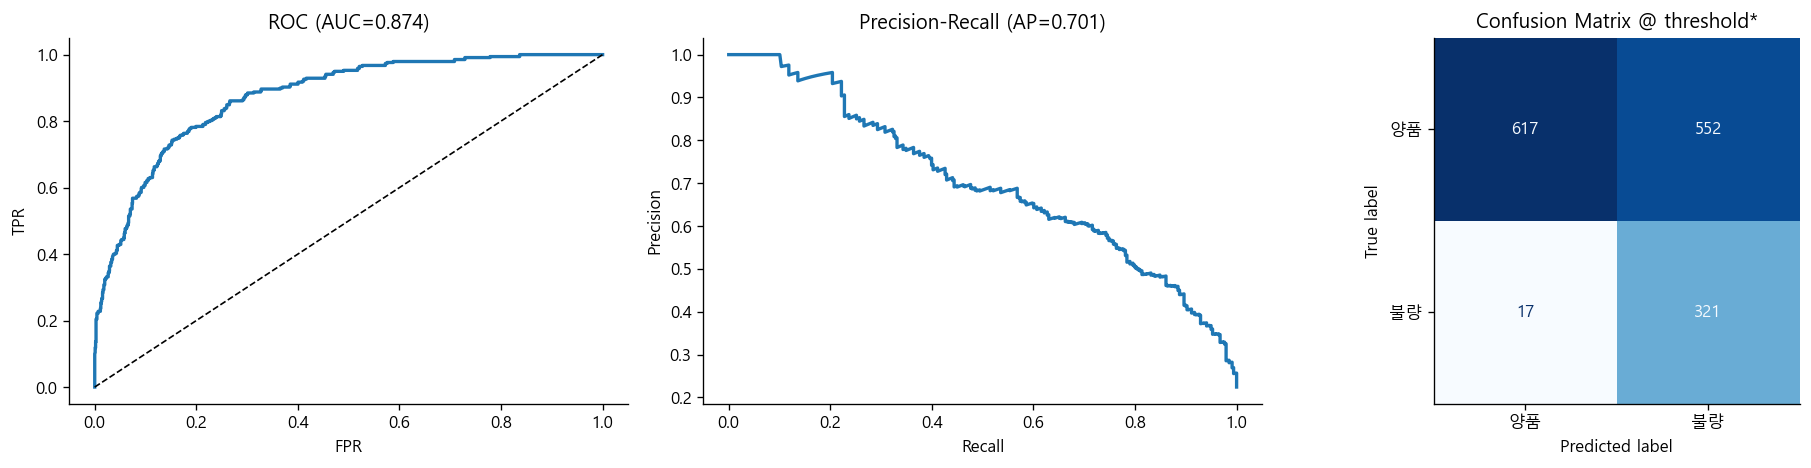

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 필수 객체 확인
if 'binary_calibrated' not in globals():
    raise NameError("binary_calibrated가 없습니다. STEP1 셀을 먼저 실행하세요.")
if 'best_threshold' not in globals():
    raise NameError("best_threshold가 없습니다. STEP1 셀을 먼저 실행하세요.")
if not all(k in globals() for k in ['X_test_', 'y_test_']):
    raise NameError("X_test_ / y_test_가 없습니다. STEP1 셀을 먼저 실행하세요.")

proba = binary_calibrated.predict_proba(X_test_)[:, 1]
thr = float(best_threshold)
pred = (proba >= thr).astype(int)

# ROC / PR
roc = roc_auc_score(y_test_, proba)
pr  = average_precision_score(y_test_, proba)

print(f"[Test] ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f} | threshold*: {thr:.3f}")
print("\n[Classification Report @ threshold*]")
print(classification_report(y_test_, pred, digits=4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ROC
fpr, tpr, _ = roc_curve(y_test_, proba)
axes[0].plot(fpr, tpr, linewidth=2)
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_title(f"ROC (AUC={roc:.3f})")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")

# PR
prec, rec, _ = precision_recall_curve(y_test_, proba)
axes[1].plot(rec, prec, linewidth=2)
axes[1].set_title(f"Precision-Recall (AP={pr:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")

# Confusion matrix
cm = confusion_matrix(y_test_, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["양품","불량"])
disp.plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title("Confusion Matrix @ threshold*")

plt.tight_layout()
plt.show()


## 6️. 중요 변수 분석
- Permutation Importance(검증셋 기반) + XGBoost 내장 중요도를 함께 확인합니다.

**(무엇/왜/어떻게)**

- **무엇**: 특성 중요도(퍼뮤테이션 중요도) 산출
- **왜**: 어떤 변수가 예측에 실제로 기여했는지 설명력을 높이고, 공정 개선 포인트를 찾기 위해서.
- **어떻게**: 한 변수씩 값을 섞어 성능 저하량을 측정해 중요도를 계산함.


In [24]:
import pandas as pd
from sklearn.inspection import permutation_importance

# STEP1에서 학습한 파이프라인/모델 사용
if 'binary_pipe_final' not in globals():
    raise NameError("binary_pipe_final이 없습니다. STEP1 셀을 먼저 실행하세요.")
if not all(k in globals() for k in ['X_test_', 'y_test_']):
    raise NameError("X_test_ / y_test_가 없습니다. STEP1 셀을 먼저 실행하세요.")

# Permutation Importance (ROC-AUC 기준)
pi = permutation_importance(
    binary_pipe_final, X_test_, y_test_,
    scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1
)
pi_df = (pd.DataFrame({"feature": X_test_.columns, "importance": pi.importances_mean})
           .sort_values("importance", ascending=False)
           .head(15))
display(pi_df)

# XGBoost gain 기반 중요도(참고)
xgb_model = binary_pipe_final.named_steps["model"]
try:
    booster = xgb_model.get_booster()
    gain = booster.get_score(importance_type="gain")
    gain_df = (pd.DataFrame({"feature": list(gain.keys()), "gain": list(gain.values())})
                 .sort_values("gain", ascending=False)
                 .head(15))
    display(gain_df)
except Exception as e:
    print("XGBoost gain importance 계산 실패:", e)


,feature,importance
3,Process_High_Velocity,0.0726
10,Process_Casting_Pressure,0.0367
15,Sensor_Air_Pressure,0.0303
14,Sensor_Melting_Furnace_Temp,0.0292
17,Sensor_Coolant_Pressure,0.0281
19,Sensor_Factory_Humidity,0.0252
6,Process_Biscuit_Thickness,0.0216
8,Process_Cycle_Time,0.0211
7,Process_Clamping_Force,0.0198
1,Process_Velocity_2,0.0183


,feature,gain
13,Process_Spray_2_Time,53.1328
12,Process_Spray_1_Time,53.0209
1,Process_Velocity_2,12.0066
5,Process_Rapid_Rise_Time,12.0048
6,Process_Biscuit_Thickness,11.2013
10,Process_Casting_Pressure,10.9282
4,Process_Cylinder_Pressure,8.4256
0,Process_Velocity_1,8.2844
17,Sensor_Coolant_Pressure,6.5947
15,Sensor_Air_Pressure,6.0578


## 7️. SHAP 해석
- STEP1의 최종 XGBoost 모델을 기반으로 전역/국소 해석을 수행합니다.

**(무엇/왜/어떻게)**

- **무엇**: SHAP 해석(모델이 예측한 이유를 설명)
- **왜**: 제조 현장에서는 ‘왜 불량으로 판단했는지’가 매우 중요하기 때문.
- **어떻게**: TreeExplainer/Explainer로 SHAP 값을 계산하고 summary/dependence 등으로 시각화.



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\matth\anaconda3\envs\cv\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\matth\anaconda3\envs\cv\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\matth\anaconda3\envs\cv\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\matth\

AttributeError: _ARRAY_API not found

SHAP shape: (1200, 21)


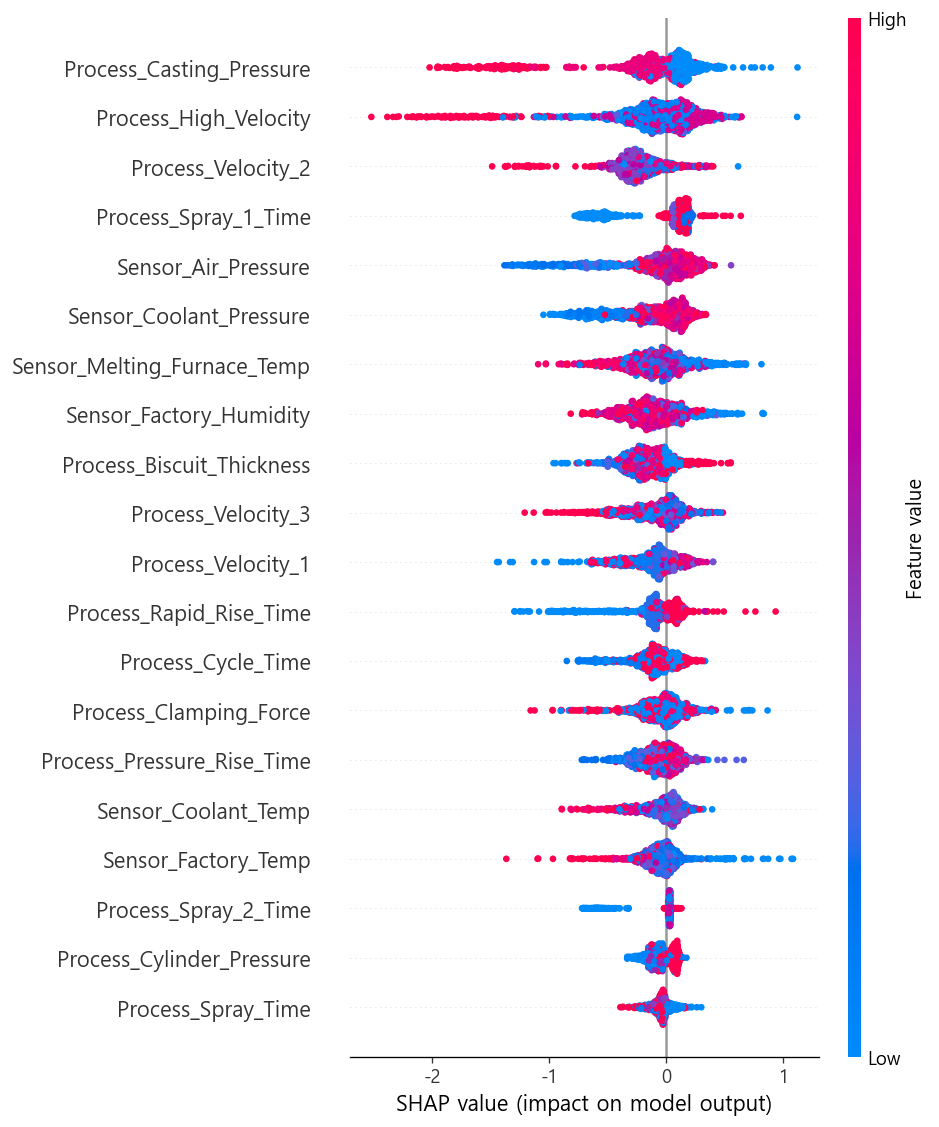

Top2 features: ['Process_Casting_Pressure', 'Process_High_Velocity']


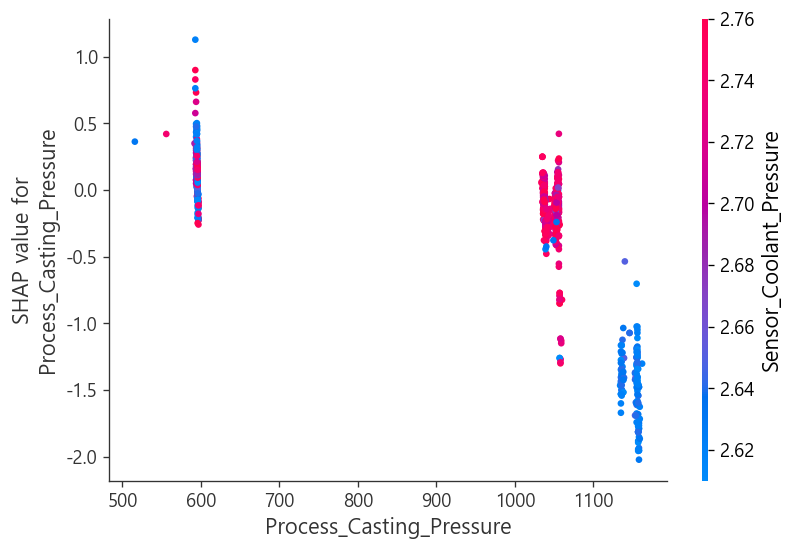

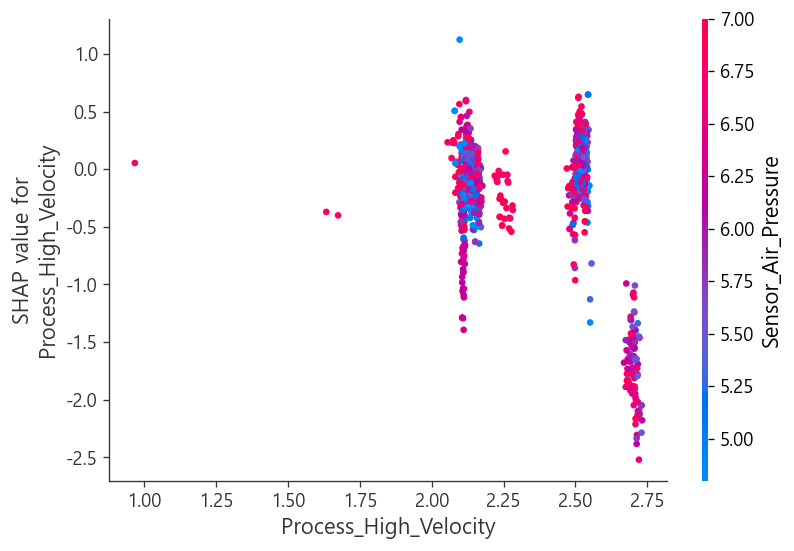

In [25]:
import shap
import numpy as np

if 'binary_pipe_final' not in globals():
    raise NameError("binary_pipe_final이 없습니다. STEP1 셀을 먼저 실행하세요.")
if not all(k in globals() for k in ['X_test_']):
    raise NameError("X_test_가 없습니다. STEP1 셀을 먼저 실행하세요.")

xgb_model = binary_pipe_final.named_steps["model"]

# SHAP 계산은 샘플링 권장(속도)
X_shap = X_test_.copy()
if len(X_shap) > 1200:
    X_shap = X_shap.sample(1200, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print("SHAP shape:", np.array(shap_values).shape)

# 전역 중요도
shap.summary_plot(shap_values, X_shap, show=True)

# 상위 변수 2개 dependence
abs_mean = np.abs(shap_values).mean(axis=0)
top2_idx = np.argsort(abs_mean)[::-1][:2]
top2 = [X_shap.columns[i] for i in top2_idx]
print("Top2 features:", top2)

for f in top2:
    shap.dependence_plot(f, shap_values, X_shap, show=True)


### 7-1. 공정 최적화 리포트 자동 생성

> SHAP 해석 결과를 **현장 의사결정용 요약 리포트(Markdown)**로 자동 생성합니다.

**(무엇/왜/어떻게)**

- **무엇**: SHAP 해석 결과 기반 공정 최적화 리포트 자동 생성
- **왜**: 분석 결과를 데이터 비전문가인 현장 담당자도 이해할 수 있는 형태로 전달하기 위해서.
- **어떻게**: 상위 SHAP 변수별 '위험 구간'을 규칙 형태로 요약하고 Markdown 파일로 저장 후 노트북에서 미리보기.


In [ ]:

# ============================================================
# STEP 3) 공정 최적화 리포트 자동 생성
#   - Binary 모델 기반 SHAP 해석
#   - 상위 변수별 "위험 구간"을 간단 규칙 형태로 요약
# ============================================================

import numpy as np
import pandas as pd
import shap
from datetime import datetime

# --- 결과 객체 확인 ---
if 'binary_pipe_final' not in globals() or 'binary_calibrated' not in globals():
    raise NameError("STEP 1을 먼저 실행해서 binary_pipe_final / binary_calibrated 를 생성하세요.")

# feature matrix 확보
if 'X_clipped' in globals():
    X_all = X_clipped.copy()
elif 'X' in globals():
    X_all = X.copy()
else:
    # 보수적 fallback
    drop_cols = [c for c in df.columns if c.startswith("Defects_")] + ['defect_any']
    X_all = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number]).copy()

# 분석 샘플(속도 고려)
SAMPLE_N = min(1500, len(X_all))
X_sample = X_all.sample(SAMPLE_N, random_state=42)

# --- SHAP 계산 (Pipeline 내 최종 모델만 대상으로) ---
# imblearn Pipeline: 마지막 스텝이 model
xgb_model = binary_pipe_final.named_steps["model"]

explainer = shap.TreeExplainer(xgb_model)
# SHAP 값은 모델 입력 feature 순서가 X_sample.columns와 동일하다고 가정(노트북 내 전처리 흐름 동일)
shap_values = explainer.shap_values(X_sample)

# 전역 중요도 top 10
abs_mean = np.abs(shap_values).mean(axis=0)
imp = pd.Series(abs_mean, index=X_sample.columns).sort_values(ascending=False)
top_feats = imp.head(10).index.tolist()

# --- 위험 구간 요약 함수 ---
def risk_bins_report(feature: str, bins: int = 4) -> pd.DataFrame:
    tmp = pd.DataFrame({
        feature: X_all[feature],
        "proba": binary_calibrated.predict_proba(X_all)[:, 1],
        "y": df["defect_any"].astype(int).values
    }).dropna()

    # qcut이 실패(중복)하면 cut로 fallback
    try:
        tmp["bin"] = pd.qcut(tmp[feature], q=bins, duplicates="drop")
    except Exception:
        tmp["bin"] = pd.cut(tmp[feature], bins=bins)

    out = tmp.groupby("bin").agg(
        n=("y", "size"),
        defect_rate=("y", "mean"),
        avg_pred_proba=("proba", "mean"),
        min_val=(feature, "min"),
        max_val=(feature, "max")
    ).reset_index(drop=True)

    out["defect_rate"] = out["defect_rate"] * 100
    out["avg_pred_proba"] = out["avg_pred_proba"] * 100
    return out.sort_values("avg_pred_proba", ascending=False)

# --- 리포트 작성 ---
lines = []
lines.append("# 다이캐스팅 공정 최적화 리포트 (Auto)\n")
lines.append(f"- 생성 시각: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
if 'best_threshold' in globals():
    lines.append(f"- 운영 권장 threshold (비용 기반): **{best_threshold:.4f}**  (FN_COST=10, FP_COST=1)\n")

# STEP2 정보
if 'top3_defects' in globals():
    lines.append("\n##  Top 3 불량 유형 (빈도 기준)\n")
    for i, d in enumerate(top3_defects, 1):
        lines.append(f"- Top{i}: `{d}`\n")

lines.append("\n##  Binary 모델 기준 주요 영향 변수 Top 10 (SHAP)\n")
for i, f in enumerate(top_feats, 1):
    lines.append(f"{i}. `{f}`\n")

lines.append("\n##  공정 변수별 '위험 구간' 요약 (상위 5개 변수)\n")
for f in top_feats[:5]:
    rb = risk_bins_report(f, bins=4).head(4).copy()
    # 최고 위험 구간 1개를 규칙 형태로
    top_row = rb.iloc[0]
    rule = f"- **{f}**: `{top_row['min_val']:.4g} ~ {top_row['max_val']:.4g}` 구간에서 " \
           f"평균 예측 불량확률 **{top_row['avg_pred_proba']:.1f}%**, 실제 불량률 **{top_row['defect_rate']:.1f}%** (n={int(top_row['n'])})\n"
    lines.append(rule)

lines.append("\n##  해석/활용 가이드\n")
lines.append("- 위 '위험 구간'은 **현재 데이터/모델 기준**으로 불량 가능성이 상대적으로 높은 범위를 요약한 것임.\n")
lines.append("- 실제 공정 적용 시에는 (1) 공정 제약조건 (2) 품질/생산성 트레이드오프 (3) 장비/제품 타입별 분리를 함께 고려해 검증할 필요가 있음.\n")
lines.append("- 추후 최적화 방향: 상위 5개 변수에 대해 **현장 기준 허용 범위**와 비교하여, 조정 가능한 변수부터 우선 개선 실험(A/B 또는 DOE)을 설계해야함.\n")

report_md = "".join(lines)
from IPython.display import Markdown, display
display(Markdown(report_md))


# 다이캐스팅 공정 최적화 리포트 (Auto)
- 생성 시각: 2026-03-03 19:44:50
- 운영 권장 threshold (비용 기반): **0.1003**  (FN_COST=10, FP_COST=1)

##  Top 3 불량 유형 (빈도 기준)
- Top1: `Defects_Short_Shot_1`
- Top2: `Defects_Blow_Hole_1`
- Top3: `Defects_Stain_1`

##  Binary 모델 기준 주요 영향 변수 Top 10 (SHAP)
1. `Process_High_Velocity`
2. `Process_Casting_Pressure`
3. `Process_Spray_1_Time`
4. `Process_Velocity_2`
5. `Sensor_Air_Pressure`
6. `Sensor_Coolant_Pressure`
7. `Sensor_Melting_Furnace_Temp`
8. `Sensor_Factory_Humidity`
9. `Process_Biscuit_Thickness`
10. `Process_Velocity_1`

##  공정 변수별 '위험 구간' 요약 (상위 5개 변수)
- **Process_High_Velocity**: `2.162 ~ 2.523` 구간에서 평균 예측 불량확률 **30.3%**, 실제 불량률 **30.9%** (n=1921)
- **Process_Casting_Pressure**: `516 ~ 596` 구간에서 평균 예측 불량확률 **28.5%**, 실제 불량률 **28.3%** (n=3150)
- **Process_Spray_1_Time**: `2.4 ~ 2.5` 구간에서 평균 예측 불량확률 **33.0%**, 실제 불량률 **31.6%** (n=136)
- **Process_Velocity_2**: `0.171 ~ 0.182` 구간에서 평균 예측 불량확률 **28.5%**, 실제 불량률 **27.8%** (n=1342)
- **Sensor_Air_Pressure**: `6.3 ~ 6.6` 구간에서 평균 예측 불량확률 **27.6%**, 실제 불량률 **27.5%** (n=1426)

##  해석/활용 가이드
- 위 '위험 구간'은 **현재 데이터/모델 기준**으로 불량 가능성이 상대적으로 높은 범위를 요약한 것임.
- 실제 공정 적용 시에는 (1) 공정 제약조건 (2) 품질/생산성 트레이드오프 (3) 장비/제품 타입별 분리를 함께 고려해 검증할 필요가 있음.
- 추후 최적화 방향: 상위 5개 변수에 대해 **현장 기준 허용 범위**와 비교하여, 조정 가능한 변수부터 우선 개선 실험(A/B 또는 DOE)을 설계해야함.
